Repo root detected: D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests
Train dir: D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\MINDsmall_train
Dev dir:   D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\MINDsmall_dev

=== Loaded train split ===
behaviors shape: (156965, 10)
news shape: (51282, 8)

=== Loaded dev split ===
behaviors shape: (73152, 10)
news shape: (42416, 8)

=== Train sanity checks ===
Time range: 2019-11-09 00:00:19 -> 2019-11-14 23:59:13
Num impressions: 156965
Num unique users: 50000
Avg candidates per impression: 37.22768770107986
Median candidates per impression: 24.0
Avg history length: 32.53998662122129
Median history length: 19.0
Avg clicked items per impression: 1.5057114643391838
Missing timestamps: 0

=== Random sample impression ===
impression_id: 118114
user_id: U12078
time: 2019-11-11 13:11:14
history_len: 23
num_candidates: 35
history_list (

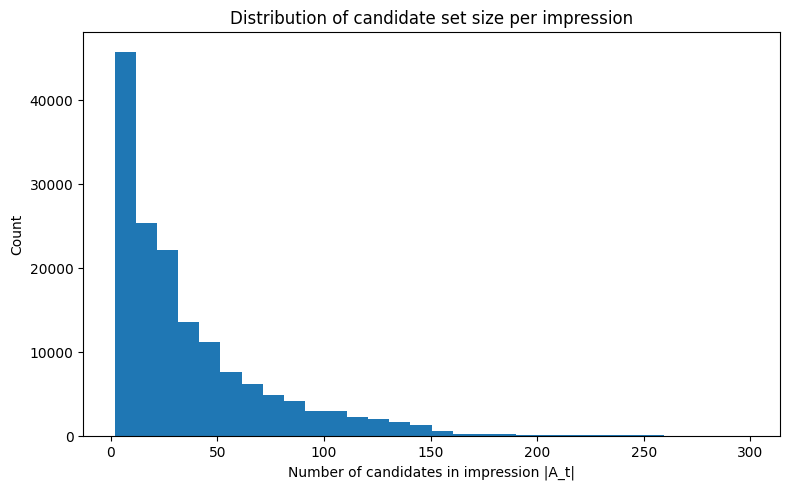

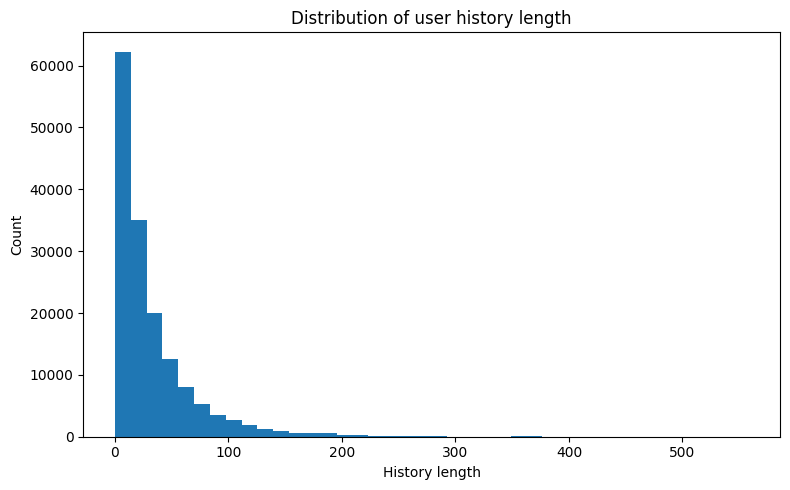

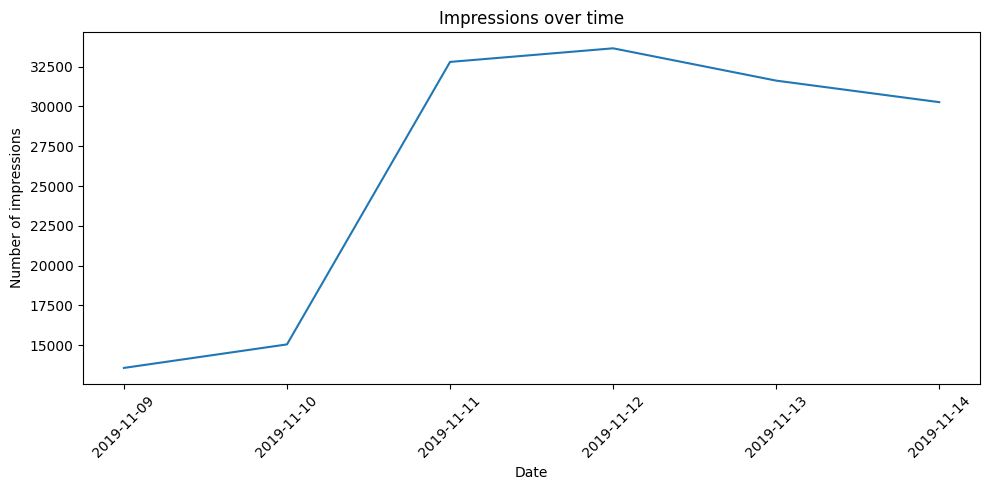

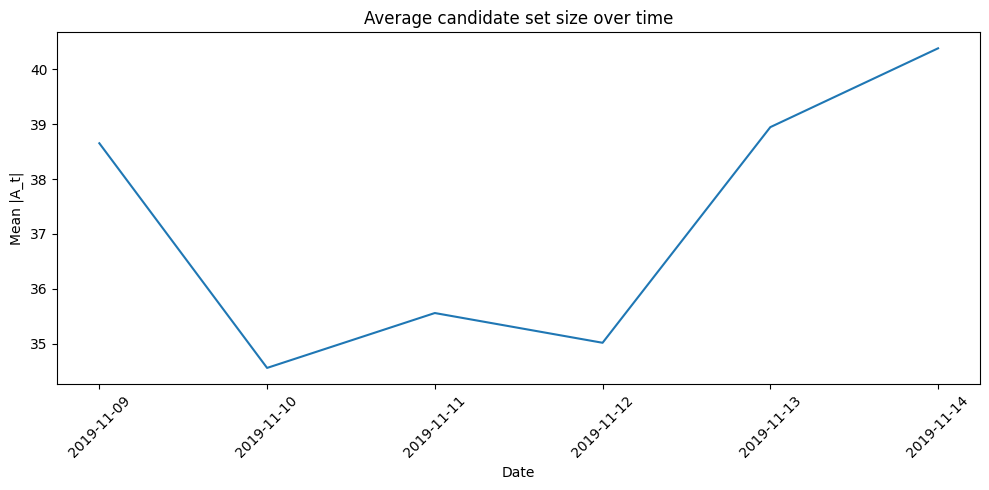

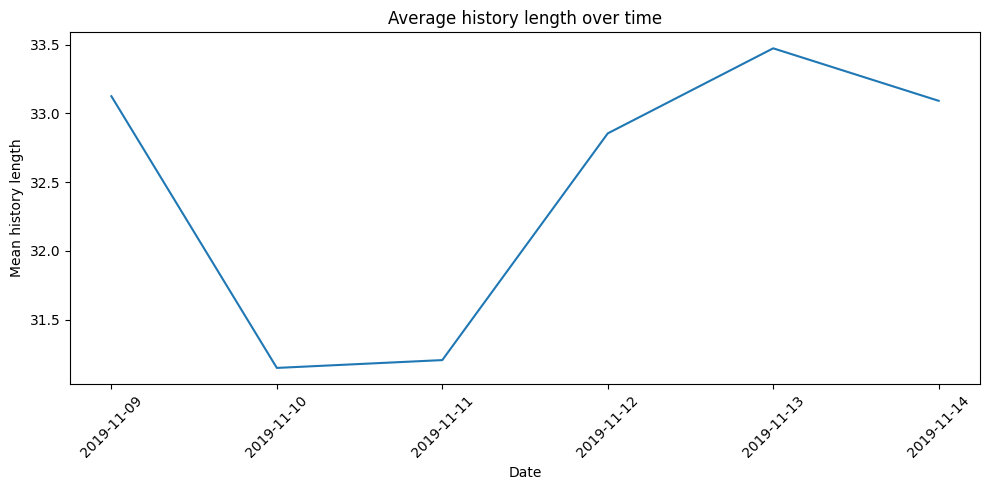

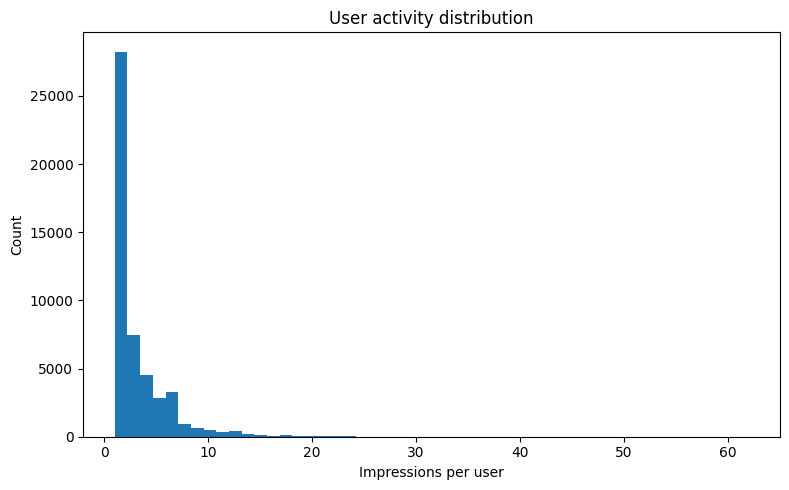

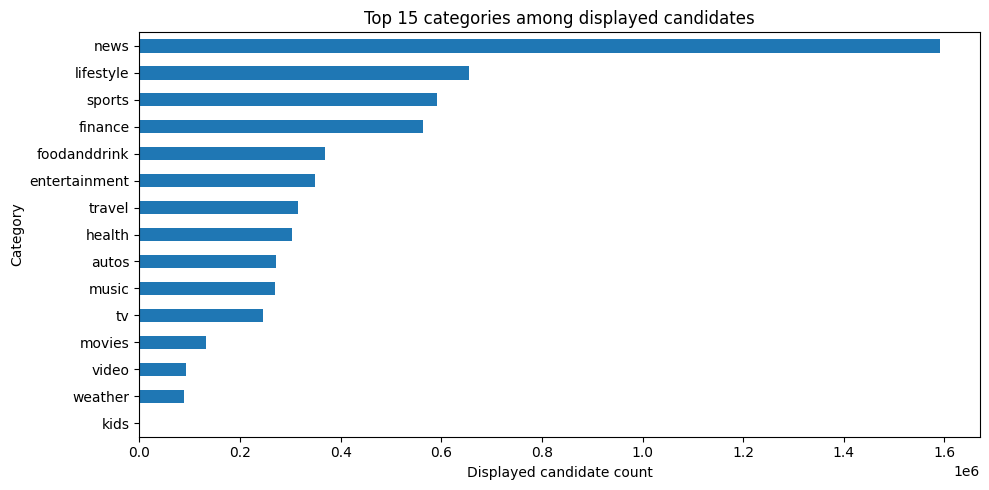

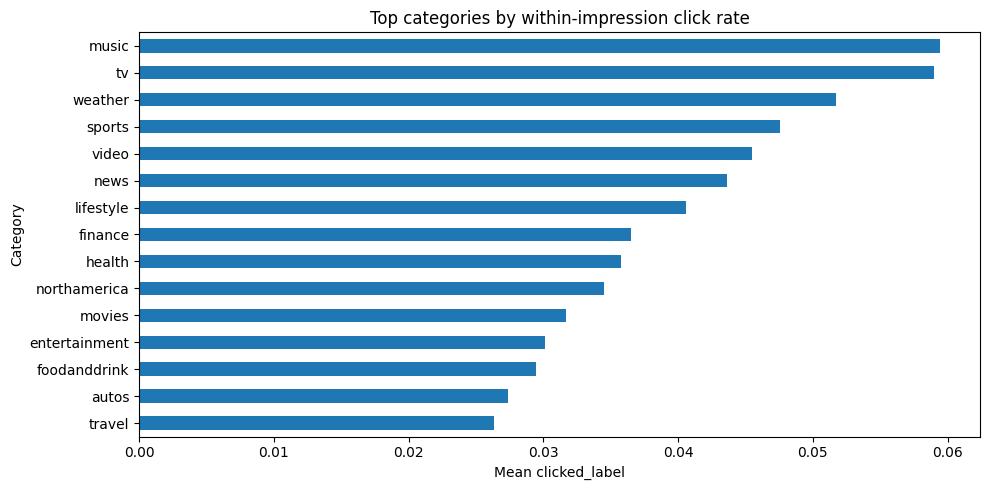

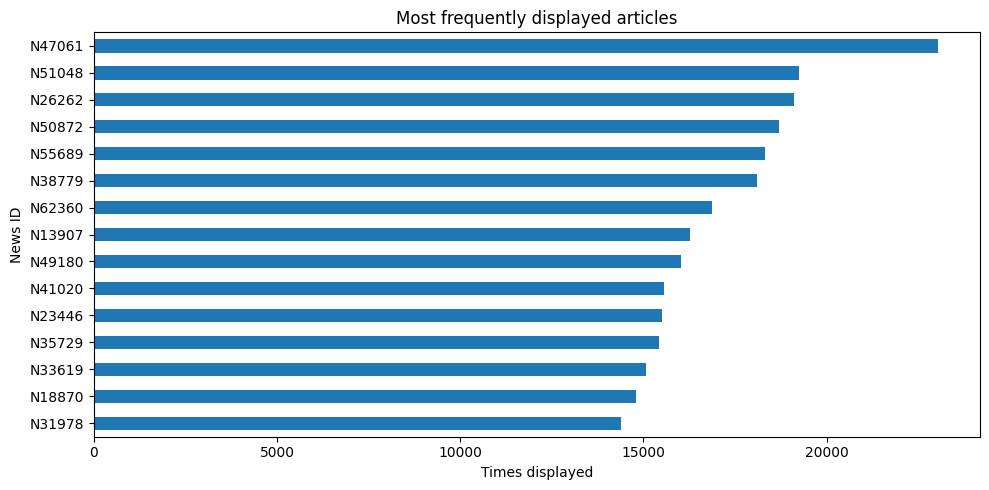


=== Train vs Dev summary ===


,split,num_impressions,num_users,avg_candidates,avg_history_len,avg_clicked_per_impression,min_time,max_time
0,train,156965,50000,37.227688,32.539987,1.505711,2019-11-09 00:00:19,2019-11-14 23:59:13
1,dev,73152,50000,37.469898,32.295959,1.522624,2019-11-15 00:00:01,2019-11-15 23:58:03



=== Round-level preview ===


,impression_id,user_id,time,history_list,impression_list,num_candidates,history_len,num_clicked_in_impression
0,1,U13740,2019-11-11 09:05:58,"[N55189, N42782, N34694, N45794, N18445, N6330...","[(N55689, 1), (N35729, 0)]",2,9,1
1,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...","[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...",11,82,1
2,3,U73700,2019-11-14 07:01:48,"[N10732, N25792, N7563, N21087, N41087, N5445,...","[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...",36,16,1
3,4,U34670,2019-11-11 05:28:05,"[N45729, N2203, N871, N53880, N41375, N43142, ...","[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...",4,10,1
4,5,U8125,2019-11-12 16:11:21,"[N10078, N56514, N14904, N33740]","[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...",69,4,1



Done. You now have:
- behaviors dataframe with parsed history and candidate pools
- candidate-level dataframe joined with article metadata
- summary plots for temporal structure and pool composition


In [1]:
# === MIND-small raw data inspection + visualization ===
# Works if your notebook is inside ./notebooks or at repo root.
# It loads behaviors.tsv + news.tsv, parses history/impressions,
# prints key summaries, and makes several diagnostic plots.

from pathlib import Path
import random
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Resolve paths
# -----------------------------
CANDIDATE_ROOTS = [
    Path("."),
    Path(".."),
]

repo_root = None
for p in CANDIDATE_ROOTS:
    if (p / "data" / "raw" / "MINDsmall_train").exists():
        repo_root = p.resolve()
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not find data/raw/MINDsmall_train.\n"
        "Run this notebook either from repo root or from the notebooks/ folder."
    )

train_dir = repo_root / "data" / "raw" / "MINDsmall_train"
dev_dir   = repo_root / "data" / "raw" / "MINDsmall_dev"

print(f"Repo root detected: {repo_root}")
print(f"Train dir: {train_dir}")
print(f"Dev dir:   {dev_dir}")

# -----------------------------
# 2) Helper parsers
# -----------------------------
def parse_history(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return str(x).split()

def parse_impressions(x):
    """
    Input example:
        'N12345-0 N67890-1 N99999-0'
    Output:
        [('N12345', 0), ('N67890', 1), ('N99999', 0)]
    """
    if pd.isna(x) or str(x).strip() == "":
        return []
    out = []
    for token in str(x).split():
        news_id, label = token.rsplit("-", 1)
        out.append((news_id, int(label)))
    return out

def load_behaviors(path):
    df = pd.read_table(
        path,
        header=None,
        names=["impression_id", "user_id", "time", "history", "impressions"]
    )
    df["time"] = pd.to_datetime(df["time"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
    df["history_list"] = df["history"].apply(parse_history)
    df["impression_list"] = df["impressions"].apply(parse_impressions)

    df["num_candidates"] = df["impression_list"].apply(len)
    df["history_len"] = df["history_list"].apply(len)
    df["num_clicked_in_impression"] = df["impression_list"].apply(lambda lst: sum(lbl for _, lbl in lst))
    return df

def load_news(path):
    df = pd.read_table(
        path,
        header=None,
        names=[
            "news_id",
            "category",
            "subcategory",
            "title",
            "abstract",
            "url",
            "title_entities",
            "abstract_entities",
        ],
    )
    return df

# -----------------------------
# 3) Load raw files
# -----------------------------
beh_train = load_behaviors(train_dir / "behaviors.tsv")
news_train = load_news(train_dir / "news.tsv")

print("\n=== Loaded train split ===")
print("behaviors shape:", beh_train.shape)
print("news shape:", news_train.shape)

# Optional: load dev too if you want quick comparison
load_dev = dev_dir.exists()

if load_dev:
    beh_dev = load_behaviors(dev_dir / "behaviors.tsv")
    news_dev = load_news(dev_dir / "news.tsv")
    print("\n=== Loaded dev split ===")
    print("behaviors shape:", beh_dev.shape)
    print("news shape:", news_dev.shape)

# -----------------------------
# 4) Quick sanity checks
# -----------------------------
print("\n=== Train sanity checks ===")
print("Time range:", beh_train["time"].min(), "->", beh_train["time"].max())
print("Num impressions:", len(beh_train))
print("Num unique users:", beh_train["user_id"].nunique())
print("Avg candidates per impression:", beh_train["num_candidates"].mean())
print("Median candidates per impression:", beh_train["num_candidates"].median())
print("Avg history length:", beh_train["history_len"].mean())
print("Median history length:", beh_train["history_len"].median())
print("Avg clicked items per impression:", beh_train["num_clicked_in_impression"].mean())
print("Missing timestamps:", beh_train["time"].isna().sum())

# Show a sample row
sample_idx = random.randrange(len(beh_train))
sample_row = beh_train.iloc[sample_idx]
print("\n=== Random sample impression ===")
print("impression_id:", sample_row["impression_id"])
print("user_id:", sample_row["user_id"])
print("time:", sample_row["time"])
print("history_len:", sample_row["history_len"])
print("num_candidates:", sample_row["num_candidates"])
print("history_list (first 10):", sample_row["history_list"][:10])
print("impression_list (first 10):", sample_row["impression_list"][:10])

# -----------------------------
# 5) Explode impressions into candidate-level rows
# -----------------------------
rows = []
for _, row in beh_train.iterrows():
    for news_id, label in row["impression_list"]:
        rows.append({
            "impression_id": row["impression_id"],
            "user_id": row["user_id"],
            "time": row["time"],
            "history_len": row["history_len"],
            "candidate_news_id": news_id,
            "clicked_label": label,
        })

cand_train = pd.DataFrame(rows)
cand_train = cand_train.merge(
    news_train[["news_id", "category", "subcategory", "title", "abstract"]],
    left_on="candidate_news_id",
    right_on="news_id",
    how="left",
)

print("\n=== Candidate-level train table ===")
print(cand_train.shape)
print("Missing article metadata rate:", cand_train["news_id"].isna().mean())

# -----------------------------
# 6) Derived summaries
# -----------------------------
# impressions per user
user_counts = beh_train["user_id"].value_counts().sort_values(ascending=False)

# impressions per day
daily_impressions = (
    beh_train.assign(date=beh_train["time"].dt.date)
    .groupby("date")
    .size()
    .rename("num_impressions")
)

# avg candidates over time (daily)
daily_candidates = (
    beh_train.assign(date=beh_train["time"].dt.date)
    .groupby("date")["num_candidates"]
    .mean()
)

# avg history length over time (daily)
daily_history = (
    beh_train.assign(date=beh_train["time"].dt.date)
    .groupby("date")["history_len"]
    .mean()
)

# category frequency among displayed candidates
category_counts = (
    cand_train["category"]
    .fillna("MISSING")
    .value_counts()
)

# click-through rate by category among displayed candidates
ctr_by_category = (
    cand_train.groupby("category")["clicked_label"]
    .mean()
    .sort_values(ascending=False)
)

# most frequent articles in displayed candidate pools
top_articles = cand_train["candidate_news_id"].value_counts().head(15)

# -----------------------------
# 7) Plots
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(beh_train["num_candidates"], bins=30)
plt.xlabel("Number of candidates in impression |A_t|")
plt.ylabel("Count")
plt.title("Distribution of candidate set size per impression")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(beh_train["history_len"], bins=40)
plt.xlabel("History length")
plt.ylabel("Count")
plt.title("Distribution of user history length")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(daily_impressions.index, daily_impressions.values)
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of impressions")
plt.title("Impressions over time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(daily_candidates.index, daily_candidates.values)
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Mean |A_t|")
plt.title("Average candidate set size over time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(daily_history.index, daily_history.values)
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Mean history length")
plt.title("Average history length over time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(user_counts.values, bins=50)
plt.xlabel("Impressions per user")
plt.ylabel("Count")
plt.title("User activity distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
top_n_cat = 15
category_counts.head(top_n_cat).sort_values().plot(kind="barh")
plt.xlabel("Displayed candidate count")
plt.ylabel("Category")
plt.title(f"Top {top_n_cat} categories among displayed candidates")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
ctr_plot = ctr_by_category.dropna().head(15).sort_values()
ctr_plot.plot(kind="barh")
plt.xlabel("Mean clicked_label")
plt.ylabel("Category")
plt.title("Top categories by within-impression click rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
top_articles.sort_values().plot(kind="barh")
plt.xlabel("Times displayed")
plt.ylabel("News ID")
plt.title("Most frequently displayed articles")
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Optional: compare train vs dev basic stats
# -----------------------------
if load_dev:
    compare = pd.DataFrame({
        "split": ["train", "dev"],
        "num_impressions": [len(beh_train), len(beh_dev)],
        "num_users": [beh_train["user_id"].nunique(), beh_dev["user_id"].nunique()],
        "avg_candidates": [beh_train["num_candidates"].mean(), beh_dev["num_candidates"].mean()],
        "avg_history_len": [beh_train["history_len"].mean(), beh_dev["history_len"].mean()],
        "avg_clicked_per_impression": [
            beh_train["num_clicked_in_impression"].mean(),
            beh_dev["num_clicked_in_impression"].mean(),
        ],
        "min_time": [beh_train["time"].min(), beh_dev["time"].min()],
        "max_time": [beh_train["time"].max(), beh_dev["time"].max()],
    })
    print("\n=== Train vs Dev summary ===")
    display(compare)

# -----------------------------
# 9) Build a round-level object preview for your bandit pipeline
# -----------------------------
rounds_preview = beh_train[[
    "impression_id", "user_id", "time", "history_list", "impression_list",
    "num_candidates", "history_len", "num_clicked_in_impression"
]].copy()

print("\n=== Round-level preview ===")
display(rounds_preview.head())

print("\nDone. You now have:")
print("- behaviors dataframe with parsed history and candidate pools")
print("- candidate-level dataframe joined with article metadata")
print("- summary plots for temporal structure and pool composition")

In [2]:
# === Build and save canonical round-level tables (robust version) ===

from pathlib import Path
import pandas as pd

processed_dir = repo_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

def build_round_table(beh_df: pd.DataFrame) -> pd.DataFrame:
    rounds_df = beh_df[[
        "impression_id",
        "user_id",
        "time",
        "history_list",
        "impression_list",
        "num_candidates",
        "history_len",
        "num_clicked_in_impression",
    ]].copy()

    rounds_df["A_t_news_ids"] = rounds_df["impression_list"].apply(
        lambda lst: [news_id for news_id, _ in lst]
    )
    rounds_df["A_t_click_labels"] = rounds_df["impression_list"].apply(
        lambda lst: [label for _, label in lst]
    )

    rounds_df = rounds_df.drop(columns=["impression_list"])
    rounds_df = rounds_df.sort_values(
        ["user_id", "time", "impression_id"]
    ).reset_index(drop=True)

    return rounds_df

rounds_train = build_round_table(beh_train)

# Save nested/list table as pickle
rounds_train.to_pickle(processed_dir / "rounds_train.pkl")

# Save flat tables
news_train_small = news_train[[
    "news_id", "category", "subcategory", "title", "abstract"
]].copy()

news_train_small.to_parquet(processed_dir / "news_train.parquet", index=False)
cand_train.to_parquet(processed_dir / "candidates_train.parquet", index=False)

print("Saved:")
print(processed_dir / "rounds_train.pkl")
print(processed_dir / "news_train.parquet")
print(processed_dir / "candidates_train.parquet")

print("\nrounds_train shape:", rounds_train.shape)
display(rounds_train.head(3))

# Optional: same for dev
if load_dev:
    cand_rows_dev = []
    for _, row in beh_dev.iterrows():
        for news_id, label in row["impression_list"]:
            cand_rows_dev.append({
                "impression_id": row["impression_id"],
                "user_id": row["user_id"],
                "time": row["time"],
                "history_len": row["history_len"],
                "candidate_news_id": news_id,
                "clicked_label": label,
            })

    cand_dev = pd.DataFrame(cand_rows_dev)
    cand_dev = cand_dev.merge(
        news_dev[["news_id", "category", "subcategory", "title", "abstract"]],
        left_on="candidate_news_id",
        right_on="news_id",
        how="left"
    )

    rounds_dev = build_round_table(beh_dev)
    rounds_dev.to_pickle(processed_dir / "rounds_dev.pkl")

    news_dev_small = news_dev[[
        "news_id", "category", "subcategory", "title", "abstract"
    ]].copy()
    news_dev_small.to_parquet(processed_dir / "news_dev.parquet", index=False)
    cand_dev.to_parquet(processed_dir / "candidates_dev.parquet", index=False)

    print("\nAlso saved dev split:")
    print(processed_dir / "rounds_dev.pkl")
    print(processed_dir / "news_dev.parquet")
    print(processed_dir / "candidates_dev.parquet")

Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\rounds_train.pkl
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\news_train.parquet
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\candidates_train.parquet

rounds_train shape: (156965, 9)


,impression_id,user_id,time,history_list,num_candidates,history_len,num_clicked_in_impression,A_t_news_ids,A_t_click_labels
0,107691,U100,2019-11-12 07:34:12,"[N20121, N33998, N45954, N55743, N50095, N1887...",105,10,1,"[N61235, N54489, N42597, N7800, N61408, N26415...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,86767,U1000,2019-11-13 23:16:18,"[N29641, N1789, N41244]",56,3,1,"[N35273, N7618, N55281, N4021, N16148, N3841, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,46640,U1000,2019-11-14 01:00:56,"[N29641, N1789, N41244]",92,3,2,"[N16148, N43628, N13094, N32774, N57034, N2973...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."



Also saved dev split:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\rounds_dev.pkl
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\news_dev.parquet
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\candidates_dev.parquet


Loaded news table: (51282, 5)


,news_id,category,subcategory,title,abstract
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...



After cleaning/dedup: (51282, 6)
Missing news_id: 0
Empty text rows: 0

TF-IDF shape: (51282, 5000)
Dense article feature matrix Z shape: (51282, 32)
Explained variance ratio sum: 0.08270867590870445

Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\article_features_train.npy
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\article_feature_index_train.csv


,news_id,category,subcategory,title,abstract,feature_row,title_len,abstract_len
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",0,70,73
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,1,29,116
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,2,63,196
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",3,59,99
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",4,57,179


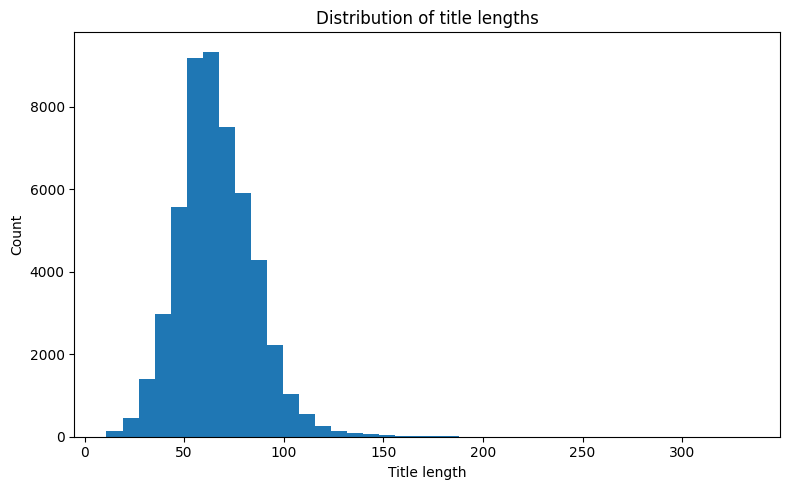

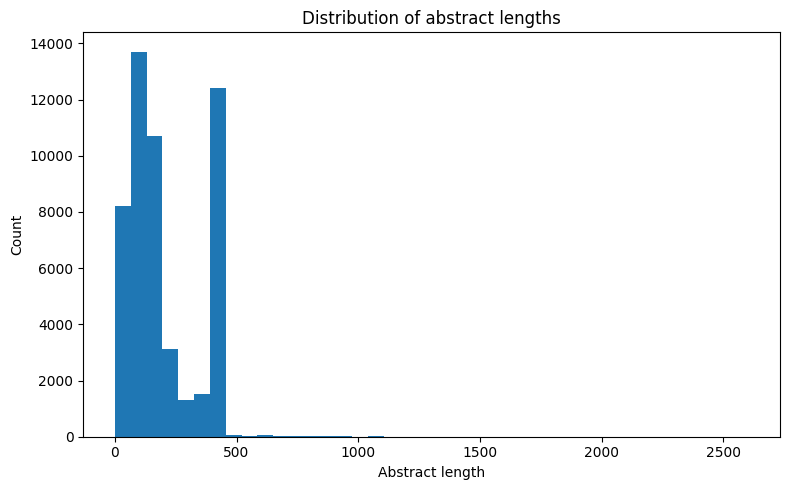

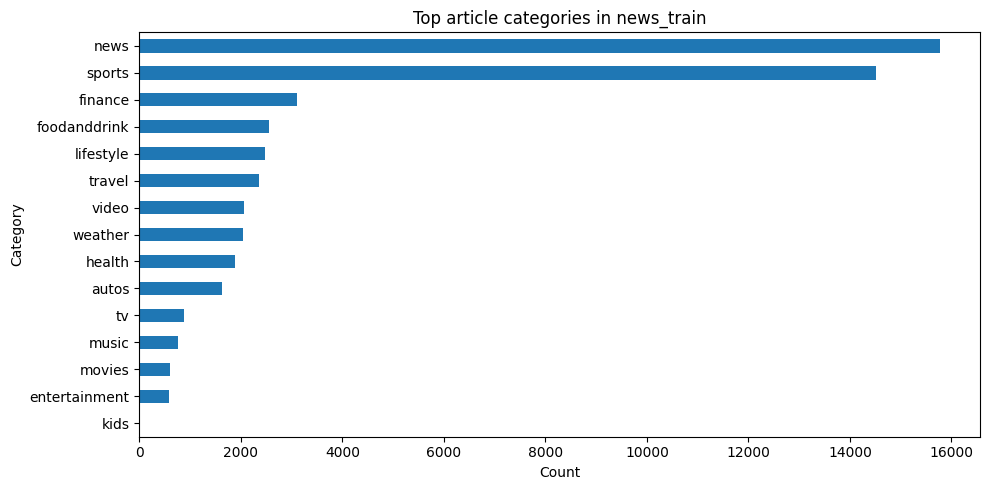

In [3]:
# === Step 3: build article features z(a) from news metadata ===

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# -----------------------------
# 1) Load processed news table
# -----------------------------
if (repo_root / "data" / "processed" / "news_train.parquet").exists():
    news_feat = pd.read_parquet(repo_root / "data" / "processed" / "news_train.parquet")
else:
    news_feat = pd.read_csv(repo_root / "data" / "processed" / "news_train.csv")

print("Loaded news table:", news_feat.shape)
display(news_feat.head(3))

# -----------------------------
# 2) Clean fields
# -----------------------------
for col in ["category", "subcategory", "title", "abstract"]:
    news_feat[col] = news_feat[col].fillna("").astype(str)

# One text field per article
news_feat["text_for_features"] = (
    "cat_" + news_feat["category"] + " "
    + "subcat_" + news_feat["subcategory"] + " "
    + news_feat["title"] + " "
    + news_feat["abstract"]
)

# Remove duplicate article IDs if any
news_feat = news_feat.drop_duplicates(subset=["news_id"]).reset_index(drop=True)

print("\nAfter cleaning/dedup:", news_feat.shape)
print("Missing news_id:", news_feat["news_id"].isna().sum())
print("Empty text rows:", (news_feat["text_for_features"].str.len() == 0).sum())

# -----------------------------
# 3) TF-IDF -> low-dim dense vector
# -----------------------------
max_features = 5000
svd_dim = 32   # good first choice; later we can try 16/32/64

tfidf = TfidfVectorizer(
    max_features=max_features,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

X_tfidf = tfidf.fit_transform(news_feat["text_for_features"])
print("\nTF-IDF shape:", X_tfidf.shape)

actual_svd_dim = min(svd_dim, X_tfidf.shape[1] - 1) if X_tfidf.shape[1] > 1 else 1
svd = TruncatedSVD(n_components=actual_svd_dim, random_state=0)
Z = svd.fit_transform(X_tfidf)

# L2 normalize so article vectors are bounded
Z = normalize(Z, norm="l2")

print("Dense article feature matrix Z shape:", Z.shape)
print("Explained variance ratio sum:", float(svd.explained_variance_ratio_.sum()))

# -----------------------------
# 4) Save article features
# -----------------------------
feature_dir = repo_root / "data" / "processed"
feature_dir.mkdir(parents=True, exist_ok=True)

np.save(feature_dir / "article_features_train.npy", Z)

article_feature_index = news_feat[[
    "news_id", "category", "subcategory", "title", "abstract"
]].copy()
article_feature_index["feature_row"] = np.arange(len(article_feature_index))
article_feature_index.to_csv(feature_dir / "article_feature_index_train.csv", index=False)

print("\nSaved:")
print(feature_dir / "article_features_train.npy")
print(feature_dir / "article_feature_index_train.csv")

# -----------------------------
# 5) Quick diagnostics
# -----------------------------
article_feature_index["title_len"] = article_feature_index["title"].fillna("").astype(str).str.len()
article_feature_index["abstract_len"] = article_feature_index["abstract"].fillna("").astype(str).str.len()

display(article_feature_index.head(5))

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(article_feature_index["title_len"], bins=40)
plt.xlabel("Title length")
plt.ylabel("Count")
plt.title("Distribution of title lengths")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(article_feature_index["abstract_len"], bins=40)
plt.xlabel("Abstract length")
plt.ylabel("Count")
plt.title("Distribution of abstract lengths")
plt.tight_layout()
plt.show()

# Top categories
plt.figure(figsize=(10, 5))
article_feature_index["category"].value_counts().head(15).sort_values().plot(kind="barh")
plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Top article categories in news_train")
plt.tight_layout()
plt.show()

In [4]:
# === Step 4: map train rounds to article feature-row indices ===

import numpy as np
import pandas as pd
from pathlib import Path

processed_dir = repo_root / "data" / "processed"

# -----------------------------
# 1) Load round table + feature index
# -----------------------------
rounds_train = pd.read_pickle(processed_dir / "rounds_train.pkl")
article_feature_index_train = pd.read_csv(processed_dir / "article_feature_index_train.csv")

print("rounds_train shape:", rounds_train.shape)
print("article_feature_index_train shape:", article_feature_index_train.shape)

# -----------------------------
# 2) Build lookup: news_id -> feature_row
# -----------------------------
newsid_to_row = dict(
    zip(article_feature_index_train["news_id"], article_feature_index_train["feature_row"])
)

# -----------------------------
# 3) Map candidate sets and histories
# -----------------------------
def map_news_ids_to_rows(news_ids, lookup):
    return [lookup[nid] for nid in news_ids if nid in lookup]

rounds_train["A_t_feature_rows"] = rounds_train["A_t_news_ids"].apply(
    lambda ids: map_news_ids_to_rows(ids, newsid_to_row)
)

rounds_train["history_feature_rows"] = rounds_train["history_list"].apply(
    lambda ids: map_news_ids_to_rows(ids, newsid_to_row)
)

# -----------------------------
# 4) Diagnostics
# -----------------------------
rounds_train["mapped_num_candidates"] = rounds_train["A_t_feature_rows"].apply(len)
rounds_train["mapped_history_len"] = rounds_train["history_feature_rows"].apply(len)

candidate_coverage = (
    rounds_train["mapped_num_candidates"].sum() /
    rounds_train["num_candidates"].sum()
)

history_coverage = (
    rounds_train["mapped_history_len"].sum() /
    rounds_train["history_len"].replace(0, np.nan).sum()
)

print("\n=== Mapping diagnostics ===")
print("Candidate coverage:", candidate_coverage)
print("Avg mapped candidates per impression:", rounds_train["mapped_num_candidates"].mean())
print("Avg mapped history length:", rounds_train["mapped_history_len"].mean())
print("Rows with zero mapped candidates:", (rounds_train["mapped_num_candidates"] == 0).sum())
print("Rows with zero mapped history:", (rounds_train["mapped_history_len"] == 0).sum())

# -----------------------------
# 5) Save enriched round table
# -----------------------------
rounds_train.to_pickle(processed_dir / "rounds_train_with_rows.pkl")

print("\nSaved:")
print(processed_dir / "rounds_train_with_rows.pkl")

display(
    rounds_train[[
        "impression_id", "user_id", "time",
        "num_candidates", "mapped_num_candidates",
        "history_len", "mapped_history_len",
        "A_t_news_ids", "A_t_feature_rows",
        "history_list", "history_feature_rows"
    ]].head(3)
)

rounds_train shape: (156965, 9)
article_feature_index_train shape: (51282, 6)

=== Mapping diagnostics ===
Candidate coverage: 1.0
Avg mapped candidates per impression: 37.22768770107986
Avg mapped history length: 32.53998662122129
Rows with zero mapped candidates: 0
Rows with zero mapped history: 3238

Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\rounds_train_with_rows.pkl


,impression_id,user_id,time,num_candidates,mapped_num_candidates,history_len,mapped_history_len,A_t_news_ids,A_t_feature_rows,history_list,history_feature_rows
0,107691,U100,2019-11-12 07:34:12,105,105,10,10,"[N61235, N54489, N42597, N7800, N61408, N26415...","[6147, 34634, 43108, 49765, 48125, 39646, 4953...","[N20121, N33998, N45954, N55743, N50095, N1887...","[20003, 30642, 23089, 7630, 21333, 31347, 2087..."
1,86767,U1000,2019-11-13 23:16:18,56,56,3,3,"[N35273, N7618, N55281, N4021, N16148, N3841, ...","[20113, 50759, 49317, 339, 46848, 39246, 3082,...","[N29641, N1789, N41244]","[14824, 20019, 19730]"
2,46640,U1000,2019-11-14 01:00:56,92,92,3,3,"[N16148, N43628, N13094, N32774, N57034, N2973...","[46848, 46632, 47547, 50475, 34942, 35727, 460...","[N29641, N1789, N41244]","[14824, 20019, 19730]"


In [5]:
# === Step 5: build dev article features using train-fitted tfidf + svd, then map rounds_dev ===

import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize

processed_dir = repo_root / "data" / "processed"

# -----------------------------
# 1) Load dev news + dev rounds
# -----------------------------
# Prefer objects already in memory if they exist; otherwise load from raw/processed.
try:
    news_dev
except NameError:
    if (processed_dir / "news_dev.csv").exists():
        news_dev = pd.read_csv(processed_dir / "news_dev.csv")
    elif (processed_dir / "news_dev.parquet").exists():
        news_dev = pd.read_parquet(processed_dir / "news_dev.parquet")
    else:
        news_dev = pd.read_table(
            repo_root / "data" / "raw" / "MINDsmall_dev" / "news.tsv",
            header=None,
            names=[
                "news_id", "category", "subcategory", "title", "abstract",
                "url", "title_entities", "abstract_entities"
            ]
        )

rounds_dev = pd.read_pickle(processed_dir / "rounds_dev.pkl")

print("Loaded dev news:", news_dev.shape)
print("Loaded rounds_dev:", rounds_dev.shape)

# -----------------------------
# 2) Clean dev news text exactly like train
# -----------------------------
news_dev_feat = news_dev.copy()

for col in ["category", "subcategory", "title", "abstract"]:
    news_dev_feat[col] = news_dev_feat[col].fillna("").astype(str)

news_dev_feat["text_for_features"] = (
    "cat_" + news_dev_feat["category"] + " "
    + "subcat_" + news_dev_feat["subcategory"] + " "
    + news_dev_feat["title"] + " "
    + news_dev_feat["abstract"]
)

news_dev_feat = news_dev_feat.drop_duplicates(subset=["news_id"]).reset_index(drop=True)

print("\nAfter cleaning/dedup:", news_dev_feat.shape)

# -----------------------------
# 3) Transform dev text with TRAIN-fitted tfidf + svd
# -----------------------------
# IMPORTANT: tfidf and svd must already exist in memory from the train-feature cell.
X_dev_tfidf = tfidf.transform(news_dev_feat["text_for_features"])
Z_dev = svd.transform(X_dev_tfidf)
Z_dev = normalize(Z_dev, norm="l2")

print("X_dev_tfidf shape:", X_dev_tfidf.shape)
print("Z_dev shape:", Z_dev.shape)

# -----------------------------
# 4) Save dev article feature matrix + index
# -----------------------------
np.save(processed_dir / "article_features_dev.npy", Z_dev)

article_feature_index_dev = news_dev_feat[[
    "news_id", "category", "subcategory", "title", "abstract"
]].copy()
article_feature_index_dev["feature_row"] = np.arange(len(article_feature_index_dev))
article_feature_index_dev.to_csv(processed_dir / "article_feature_index_dev.csv", index=False)

print("\nSaved:")
print(processed_dir / "article_features_dev.npy")
print(processed_dir / "article_feature_index_dev.csv")

# -----------------------------
# 5) Map rounds_dev into dev feature-row indices
# -----------------------------
newsid_to_row_dev = dict(
    zip(article_feature_index_dev["news_id"], article_feature_index_dev["feature_row"])
)

def map_news_ids_to_rows(news_ids, lookup):
    return [lookup[nid] for nid in news_ids if nid in lookup]

rounds_dev["A_t_feature_rows"] = rounds_dev["A_t_news_ids"].apply(
    lambda ids: map_news_ids_to_rows(ids, newsid_to_row_dev)
)

rounds_dev["history_feature_rows"] = rounds_dev["history_list"].apply(
    lambda ids: map_news_ids_to_rows(ids, newsid_to_row_dev)
)

rounds_dev["mapped_num_candidates"] = rounds_dev["A_t_feature_rows"].apply(len)
rounds_dev["mapped_history_len"] = rounds_dev["history_feature_rows"].apply(len)

candidate_coverage_dev = (
    rounds_dev["mapped_num_candidates"].sum() /
    rounds_dev["num_candidates"].sum()
)

history_denom = rounds_dev["history_len"].sum()
history_coverage_dev = (
    rounds_dev["mapped_history_len"].sum() / history_denom
    if history_denom > 0 else np.nan
)

print("\n=== Dev mapping diagnostics ===")
print("Candidate coverage:", candidate_coverage_dev)
print("History coverage:", history_coverage_dev)
print("Avg mapped candidates per impression:", rounds_dev["mapped_num_candidates"].mean())
print("Avg mapped history length:", rounds_dev["mapped_history_len"].mean())
print("Rows with zero mapped candidates:", (rounds_dev["mapped_num_candidates"] == 0).sum())
print("Rows with zero mapped history:", (rounds_dev["mapped_history_len"] == 0).sum())

rounds_dev.to_pickle(processed_dir / "rounds_dev_with_rows.pkl")
print("\nSaved:")
print(processed_dir / "rounds_dev_with_rows.pkl")

display(
    rounds_dev[[
        "impression_id", "user_id", "time",
        "num_candidates", "mapped_num_candidates",
        "history_len", "mapped_history_len",
        "A_t_news_ids", "A_t_feature_rows"
    ]].head(3)
)

Loaded dev news: (42416, 8)
Loaded rounds_dev: (73152, 9)

After cleaning/dedup: (42416, 9)
X_dev_tfidf shape: (42416, 5000)
Z_dev shape: (42416, 32)

Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\article_features_dev.npy
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\article_feature_index_dev.csv

=== Dev mapping diagnostics ===
Candidate coverage: 1.0
History coverage: 1.0
Avg mapped candidates per impression: 37.469898293963254
Avg mapped history length: 32.29595909886264
Rows with zero mapped candidates: 0
Rows with zero mapped history: 2214

Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\rounds_dev_with_rows.pkl


,impression_id,user_id,time,num_candidates,mapped_num_candidates,history_len,mapped_history_len,A_t_news_ids,A_t_feature_rows
0,8158,U1,2019-11-15 07:28:25,2,2,12,12,"[N14637, N20036]","[40332, 35200]"
1,71327,U10,2019-11-15 06:08:15,54,54,7,7,"[N33397, N46917, N11930, N58612, N47612, N2362...","[40397, 38173, 7013, 35622, 36590, 40452, 4007..."
2,41696,U10000,2019-11-15 08:39:38,7,7,37,37,"[N29393, N20036, N30290, N31958, N23513, N1999...","[35881, 35200, 166, 41033, 40368, 36184, 39668]"


In [6]:
# === Step 6: build per-round history embeddings for train and dev ===

import numpy as np
import pandas as pd
from pathlib import Path

processed_dir = repo_root / "data" / "processed"

# -----------------------------
# 1) Load train/dev rounds and article matrices
# -----------------------------
rounds_train = pd.read_pickle(processed_dir / "rounds_train_with_rows.pkl")
rounds_dev   = pd.read_pickle(processed_dir / "rounds_dev_with_rows.pkl")

Z_train = np.load(processed_dir / "article_features_train.npy")
Z_dev   = np.load(processed_dir / "article_features_dev.npy")

print("rounds_train:", rounds_train.shape)
print("rounds_dev:", rounds_dev.shape)
print("Z_train:", Z_train.shape)
print("Z_dev:", Z_dev.shape)

# -----------------------------
# 2) Mean-history embedding helper
# -----------------------------
def mean_history_embedding(row_ids, Z):
    if len(row_ids) == 0:
        return np.zeros(Z.shape[1], dtype=np.float32)
    return Z[row_ids].mean(axis=0).astype(np.float32)

# -----------------------------
# 3) Build train history embeddings
# -----------------------------
H_train = np.vstack([
    mean_history_embedding(row_ids, Z_train)
    for row_ids in rounds_train["history_feature_rows"]
])

# -----------------------------
# 4) Build dev history embeddings
# -----------------------------
H_dev = np.vstack([
    mean_history_embedding(row_ids, Z_dev)
    for row_ids in rounds_dev["history_feature_rows"]
])

print("\nH_train shape:", H_train.shape)
print("H_dev shape:", H_dev.shape)

# -----------------------------
# 5) Diagnostics
# -----------------------------
train_zero_history = (rounds_train["mapped_history_len"] == 0).mean()
dev_zero_history   = (rounds_dev["mapped_history_len"] == 0).mean()

print("\n=== History embedding diagnostics ===")
print("Train zero-history fraction:", train_zero_history)
print("Dev zero-history fraction:", dev_zero_history)

print("Train history embedding norms:")
print("  min :", np.linalg.norm(H_train, axis=1).min())
print("  mean:", np.linalg.norm(H_train, axis=1).mean())
print("  max :", np.linalg.norm(H_train, axis=1).max())

print("Dev history embedding norms:")
print("  min :", np.linalg.norm(H_dev, axis=1).min())
print("  mean:", np.linalg.norm(H_dev, axis=1).mean())
print("  max :", np.linalg.norm(H_dev, axis=1).max())

# -----------------------------
# 6) Save history embedding matrices
# -----------------------------
np.save(processed_dir / "history_embeddings_train.npy", H_train)
np.save(processed_dir / "history_embeddings_dev.npy", H_dev)

print("\nSaved:")
print(processed_dir / "history_embeddings_train.npy")
print(processed_dir / "history_embeddings_dev.npy")

# -----------------------------
# 7) Optional preview
# -----------------------------
preview = rounds_train[[
    "impression_id", "user_id", "time",
    "history_len", "mapped_history_len"
]].copy()
preview["history_emb_norm"] = np.linalg.norm(H_train, axis=1)
display(preview.head(5))

rounds_train: (156965, 13)
rounds_dev: (73152, 13)
Z_train: (51282, 32)
Z_dev: (42416, 32)

H_train shape: (156965, 32)
H_dev shape: (73152, 32)

=== History embedding diagnostics ===
Train zero-history fraction: 0.02062880259930558
Dev zero-history fraction: 0.03026574803149606
Train history embedding norms:
  min : 0.0
  mean: 0.5072916
  max : 1.0
Dev history embedding norms:
  min : 0.0
  mean: 0.50220627
  max : 1.0

Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\history_embeddings_train.npy
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\history_embeddings_dev.npy


,impression_id,user_id,time,history_len,mapped_history_len,history_emb_norm
0,107691,U100,2019-11-12 07:34:12,10,10,0.583998
1,86767,U1000,2019-11-13 23:16:18,3,3,0.663892
2,46640,U1000,2019-11-14 01:00:56,3,3,0.663892
3,74345,U1000,2019-11-14 22:37:21,3,3,0.663892
4,155923,U10001,2019-11-11 05:30:21,15,15,0.494469


In [7]:
# === Step 7: define final per-candidate arm feature map phi_t(a) on demand ===

import numpy as np
import pandas as pd
from pathlib import Path

processed_dir = repo_root / "data" / "processed"

# -----------------------------
# 1) Load processed objects
# -----------------------------
rounds_train = pd.read_pickle(processed_dir / "rounds_train_with_rows.pkl")
rounds_dev   = pd.read_pickle(processed_dir / "rounds_dev_with_rows.pkl")

Z_train = np.load(processed_dir / "article_features_train.npy")
Z_dev   = np.load(processed_dir / "article_features_dev.npy")

H_train = np.load(processed_dir / "history_embeddings_train.npy")
H_dev   = np.load(processed_dir / "history_embeddings_dev.npy")

print("rounds_train:", rounds_train.shape)
print("rounds_dev:", rounds_dev.shape)
print("Z_train:", Z_train.shape)
print("Z_dev:", Z_dev.shape)
print("H_train:", H_train.shape)
print("H_dev:", H_dev.shape)

# -----------------------------
# 2) Row-wise L2 normalization
# -----------------------------
def row_l2_normalize(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

# -----------------------------
# 3) Build phi_t(a)
# -----------------------------
def build_phi_from_z_and_h(Z_candidates, h_t, normalize_rows=True):
    """
    Z_candidates: shape (K_t, d)
    h_t: shape (d,)
    returns Phi_t: shape (K_t, 4d)
    """
    K_t, d = Z_candidates.shape
    h_rep = np.repeat(h_t.reshape(1, -1), K_t, axis=0)

    Phi_t = np.concatenate([
        Z_candidates,
        h_rep,
        Z_candidates * h_rep,
        Z_candidates - h_rep,
    ], axis=1).astype(np.float32)

    if normalize_rows:
        Phi_t = row_l2_normalize(Phi_t)

    return Phi_t

# -----------------------------
# 4) Round accessor
# -----------------------------
def get_round_bundle(split, round_idx, normalize_rows=True):
    """
    Returns all objects needed for one round:
      - metadata
      - candidate article IDs
      - clicked labels (from MIND logs; not reward yet)
      - Z_candidates
      - h_t
      - Phi_t
    """
    if split == "train":
        rounds_df = rounds_train
        Z = Z_train
        H = H_train
    elif split == "dev":
        rounds_df = rounds_dev
        Z = Z_dev
        H = H_dev
    else:
        raise ValueError("split must be 'train' or 'dev'")

    row = rounds_df.iloc[round_idx]

    candidate_rows = row["A_t_feature_rows"]
    Z_candidates = Z[candidate_rows]
    h_t = H[round_idx]
    Phi_t = build_phi_from_z_and_h(Z_candidates, h_t, normalize_rows=normalize_rows)

    return {
        "impression_id": row["impression_id"],
        "user_id": row["user_id"],
        "time": row["time"],
        "candidate_news_ids": row["A_t_news_ids"],
        "clicked_labels": row["A_t_click_labels"],
        "candidate_rows": candidate_rows,
        "history_len": row["history_len"],
        "mapped_history_len": row["mapped_history_len"],
        "num_candidates": row["num_candidates"],
        "mapped_num_candidates": row["mapped_num_candidates"],
        "Z_candidates": Z_candidates,
        "h_t": h_t,
        "Phi_t": Phi_t,
    }

# -----------------------------
# 5) Smoke tests
# -----------------------------
bundle_train_0 = get_round_bundle("train", 0)
bundle_dev_0   = get_round_bundle("dev", 0)

print("\n=== Smoke test: train round 0 ===")
print("impression_id:", bundle_train_0["impression_id"])
print("user_id:", bundle_train_0["user_id"])
print("num_candidates:", bundle_train_0["num_candidates"])
print("Z_candidates shape:", bundle_train_0["Z_candidates"].shape)
print("h_t shape:", bundle_train_0["h_t"].shape)
print("Phi_t shape:", bundle_train_0["Phi_t"].shape)
print("first 5 clicked labels:", bundle_train_0["clicked_labels"][:5])

print("\n=== Smoke test: dev round 0 ===")
print("impression_id:", bundle_dev_0["impression_id"])
print("user_id:", bundle_dev_0["user_id"])
print("num_candidates:", bundle_dev_0["num_candidates"])
print("Z_candidates shape:", bundle_dev_0["Z_candidates"].shape)
print("h_t shape:", bundle_dev_0["h_t"].shape)
print("Phi_t shape:", bundle_dev_0["Phi_t"].shape)

# -----------------------------
# 6) Distribution of feature-set sizes
# -----------------------------
phi_dims = []
cand_sizes = []

sample_indices = np.linspace(0, len(rounds_train) - 1, num=min(200, len(rounds_train)), dtype=int)
for idx in sample_indices:
    b = get_round_bundle("train", int(idx))
    cand_sizes.append(b["Phi_t"].shape[0])
    phi_dims.append(b["Phi_t"].shape[1])

print("\n=== Feature diagnostics ===")
print("Unique Phi_t dimensions in sample:", sorted(set(phi_dims)))
print("Average candidate count in sample:", float(np.mean(cand_sizes)))
print("Feature dimension:", phi_dims[0] if len(phi_dims) > 0 else None)

rounds_train: (156965, 13)
rounds_dev: (73152, 13)
Z_train: (51282, 32)
Z_dev: (42416, 32)
H_train: (156965, 32)
H_dev: (73152, 32)

=== Smoke test: train round 0 ===
impression_id: 107691
user_id: U100
num_candidates: 105
Z_candidates shape: (105, 32)
h_t shape: (32,)
Phi_t shape: (105, 128)
first 5 clicked labels: [0, 0, 0, 1, 0]

=== Smoke test: dev round 0 ===
impression_id: 8158
user_id: U1
num_candidates: 2
Z_candidates shape: (2, 32)
h_t shape: (32,)
Phi_t shape: (2, 128)

=== Feature diagnostics ===
Unique Phi_t dimensions in sample: [128]
Average candidate count in sample: 40.56
Feature dimension: 128


In [8]:
# === Step 8: fit theta_star from train impressions only ===

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(0)

# -----------------------------
# 1) Collect a manageable supervised sample from train
# -----------------------------
# Strategy:
# - for each impression, use all clicked items
# - sample up to neg_per_pos non-clicked items from the same impression
# - build Phi only for those selected items

max_impressions = 30000   # safe first choice; later we can scale
neg_per_pos = 4           # sample 4 negatives per positive
skip_no_click_impressions = True

X_list = []
y_list = []

used_impressions = 0
used_positives = 0
used_negatives = 0

for t in range(min(max_impressions, len(rounds_train))):
    bundle = get_round_bundle("train", t, normalize_rows=True)
    Phi_t = bundle["Phi_t"]
    labels = np.array(bundle["clicked_labels"], dtype=int)

    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]

    if len(pos_idx) == 0:
        if skip_no_click_impressions:
            continue
        else:
            continue

    # keep all positives
    chosen_pos = pos_idx

    # sample negatives relative to positives
    num_neg_to_take = min(len(neg_idx), neg_per_pos * len(chosen_pos))
    if num_neg_to_take > 0:
        chosen_neg = rng.choice(neg_idx, size=num_neg_to_take, replace=False)
    else:
        chosen_neg = np.array([], dtype=int)

    chosen = np.concatenate([chosen_pos, chosen_neg])

    X_list.append(Phi_t[chosen])
    y_list.append(labels[chosen])

    used_impressions += 1
    used_positives += len(chosen_pos)
    used_negatives += len(chosen_neg)

X_sup = np.vstack(X_list).astype(np.float32)
y_sup = np.concatenate(y_list).astype(int)

print("Supervised design matrix shape:", X_sup.shape)
print("Used impressions:", used_impressions)
print("Used positives:", used_positives)
print("Used negatives:", used_negatives)
print("Positive rate:", y_sup.mean())

# -----------------------------
# 2) Fit a simple L2-regularized logistic model
# -----------------------------
clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=0,
)

clf.fit(X_sup, y_sup)

train_scores = clf.decision_function(X_sup)
train_auc = roc_auc_score(y_sup, train_scores)

beta_hat = clf.coef_.reshape(-1).astype(np.float32)
beta_norm = np.linalg.norm(beta_hat)

theta_star = beta_hat / max(beta_norm, 1e-12)

print("\n=== theta_star diagnostics ===")
print("beta_hat shape:", beta_hat.shape)
print("beta_hat norm:", beta_norm)
print("theta_star norm:", np.linalg.norm(theta_star))
print("Train AUC on sampled supervised set:", train_auc)

# -----------------------------
# 3) Save theta_star
# -----------------------------
np.save(processed_dir / "theta_star.npy", theta_star)

theta_info = pd.DataFrame([{
    "dim": len(theta_star),
    "beta_norm": float(beta_norm),
    "theta_norm": float(np.linalg.norm(theta_star)),
    "train_auc_sampled": float(train_auc),
    "used_impressions": int(used_impressions),
    "used_positives": int(used_positives),
    "used_negatives": int(used_negatives),
    "neg_per_pos": int(neg_per_pos),
}])
theta_info.to_csv(processed_dir / "theta_star_info.csv", index=False)

print("\nSaved:")
print(processed_dir / "theta_star.npy")
print(processed_dir / "theta_star_info.csv")

Supervised design matrix shape: (215935, 128)
Used impressions: 30000
Used positives: 45279
Used negatives: 170656
Positive rate: 0.20968810058582443

=== theta_star diagnostics ===
beta_hat shape: (128,)
beta_hat norm: 23.7646
theta_star norm: 1.0
Train AUC on sampled supervised set: 0.6418064002000026

Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\theta_star.npy
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\theta_star_info.csv


theta_star shape: (128,)
theta_star norm: 1.0


,split,num_sampled_rounds,num_sampled_candidates_total,mu_mean,mu_std,mu_min,mu_max,round_max_mean,round_min_mean,round_gap_mean,round_gap_median,avg_K
0,train,1000,36616,0.006596,0.019172,-0.048757,0.149905,0.042044,-0.018604,0.060648,0.060250,36.616
1,dev,1000,38834,0.006229,0.018827,-0.050833,0.154137,0.043277,-0.020887,0.064164,0.061914,38.834


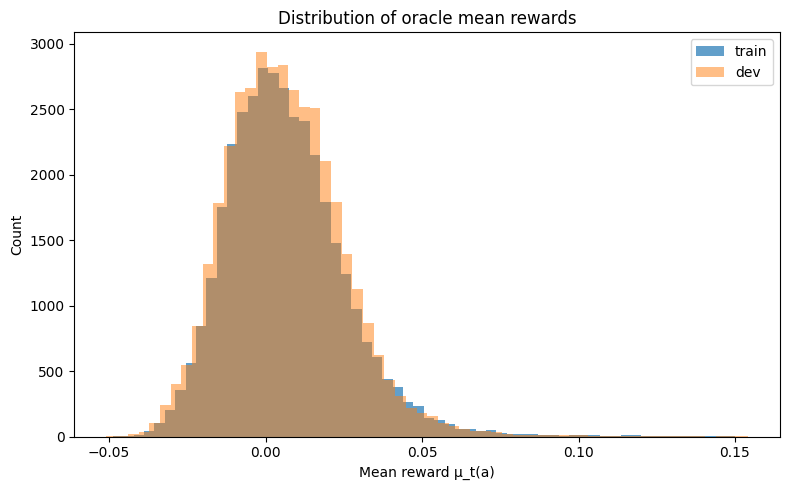


=== Example train round 0 ===
num candidates: 105
mu_t min/max: -0.023049889132380486 0.04729665070772171
first 10 mu_t: [ 0.0124 -0.0073  0.0213  0.0201 -0.0125  0.0134  0.0002  0.0473 -0.006
  0.0123]
first 10 clicked labels: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]


In [9]:
# === Step 9: define reward oracle and sanity-check reward ranges ===

import numpy as np
import pandas as pd

processed_dir = repo_root / "data" / "processed"
theta_star = np.load(processed_dir / "theta_star.npy").astype(np.float32)

print("theta_star shape:", theta_star.shape)
print("theta_star norm:", np.linalg.norm(theta_star))

# -----------------------------
# 1) Oracle helpers
# -----------------------------
def get_mu_t(split, round_idx):
    """
    Returns mean rewards mu_t(a) for all candidates in round t.
    """
    bundle = get_round_bundle(split, round_idx, normalize_rows=True)
    Phi_t = bundle["Phi_t"]               # shape (K_t, 128)
    mu_t = Phi_t @ theta_star             # shape (K_t,)
    return bundle, mu_t

def sample_reward(mu_scalar, sigma=0.05, rng=None):
    """
    One noisy reward sample for chosen action.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    return float(mu_scalar + rng.normal(0.0, sigma))

def instantaneous_pseudo_regret(mu_t, chosen_idx):
    """
    mu_t: vector of candidate means
    chosen_idx: chosen action index in current candidate set
    """
    return float(np.max(mu_t) - mu_t[chosen_idx])

# -----------------------------
# 2) Sample-based sanity checks on train/dev
# -----------------------------
def summarize_mu_distribution(split, num_rounds=1000, seed=0):
    rng = np.random.default_rng(seed)

    if split == "train":
        n_rounds = len(rounds_train)
    elif split == "dev":
        n_rounds = len(rounds_dev)
    else:
        raise ValueError("split must be 'train' or 'dev'")

    idxs = rng.choice(n_rounds, size=min(num_rounds, n_rounds), replace=False)

    all_mu = []
    per_round_max = []
    per_round_min = []
    per_round_gap = []
    per_round_K = []

    for idx in idxs:
        bundle, mu_t = get_mu_t(split, int(idx))
        all_mu.append(mu_t)
        per_round_max.append(float(mu_t.max()))
        per_round_min.append(float(mu_t.min()))
        per_round_gap.append(float(mu_t.max() - mu_t.min()))
        per_round_K.append(len(mu_t))

    all_mu = np.concatenate(all_mu)

    out = {
        "split": split,
        "num_sampled_rounds": len(idxs),
        "num_sampled_candidates_total": len(all_mu),
        "mu_mean": float(all_mu.mean()),
        "mu_std": float(all_mu.std()),
        "mu_min": float(all_mu.min()),
        "mu_max": float(all_mu.max()),
        "round_max_mean": float(np.mean(per_round_max)),
        "round_min_mean": float(np.mean(per_round_min)),
        "round_gap_mean": float(np.mean(per_round_gap)),
        "round_gap_median": float(np.median(per_round_gap)),
        "avg_K": float(np.mean(per_round_K)),
    }
    return out, all_mu

train_mu_summary, train_all_mu = summarize_mu_distribution("train", num_rounds=1000, seed=0)
dev_mu_summary, dev_all_mu     = summarize_mu_distribution("dev", num_rounds=1000, seed=1)

summary_df = pd.DataFrame([train_mu_summary, dev_mu_summary])
display(summary_df)

# -----------------------------
# 3) Optional plots
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_all_mu, bins=60, alpha=0.7, label="train")
plt.hist(dev_all_mu, bins=60, alpha=0.5, label="dev")
plt.xlabel("Mean reward μ_t(a)")
plt.ylabel("Count")
plt.title("Distribution of oracle mean rewards")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) One concrete round preview
# -----------------------------
bundle0, mu0 = get_mu_t("train", 0)
print("\n=== Example train round 0 ===")
print("num candidates:", len(mu0))
print("mu_t min/max:", float(mu0.min()), float(mu0.max()))
print("first 10 mu_t:", np.round(mu0[:10], 4))
print("first 10 clicked labels:", bundle0["clicked_labels"][:10])

=== Direct LinUCB sanity run ===
n_rounds: 5000
sigma: 0.01
lam: 1.0
alpha: 0.5
final_regret: 33.398553650360554
avg_chosen_mean: 0.03531809623760637
avg_optimal_mean: 0.04199780697175302
chosen_logged_click_rate: 0.1492


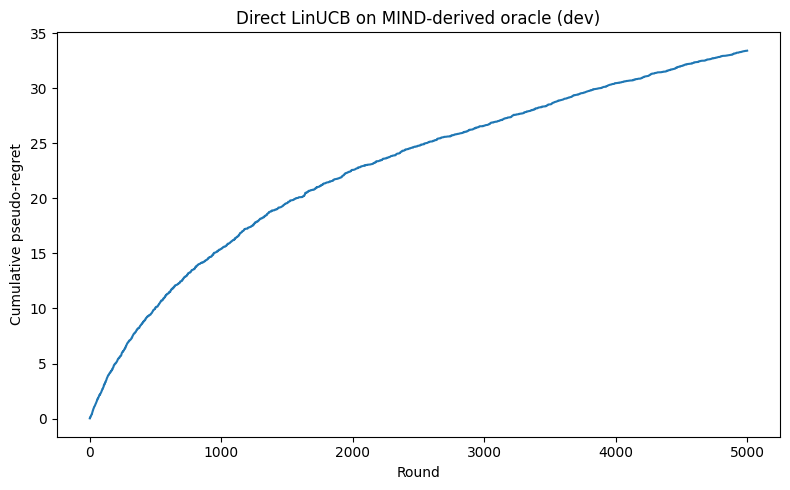

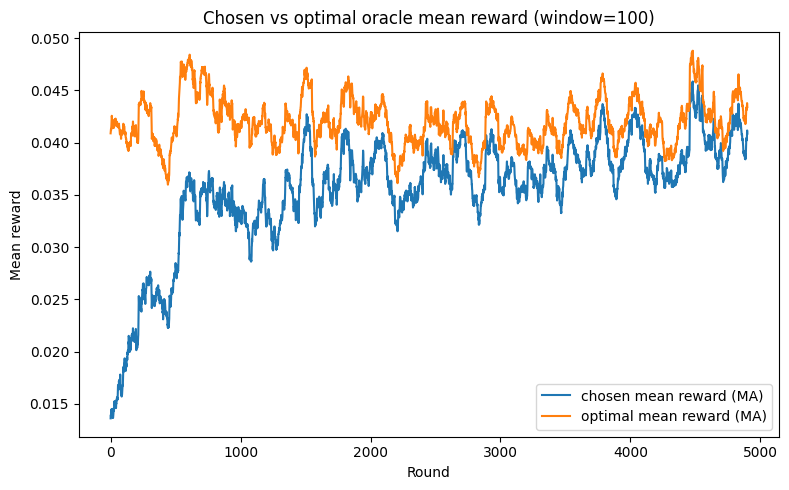

In [10]:
# === Step 10: direct LinUCB / OFUL-style sanity check on dev ===

import numpy as np
import matplotlib.pyplot as plt

processed_dir = repo_root / "data" / "processed"
theta_star = np.load(processed_dir / "theta_star.npy").astype(np.float32)

# -----------------------------
# 1) Direct linear UCB learner
# -----------------------------
class DirectLinUCB:
    def __init__(self, d, lam=1.0, alpha=0.5):
        self.d = d
        self.lam = float(lam)
        self.alpha = float(alpha)

        self.V = self.lam * np.eye(d, dtype=np.float64)
        self.b = np.zeros(d, dtype=np.float64)

    def theta_hat(self):
        return np.linalg.solve(self.V, self.b)

    def select(self, Phi_t):
        """
        Phi_t: shape (K_t, d)
        returns chosen index
        """
        V_inv = np.linalg.inv(self.V)
        theta = V_inv @ self.b

        means = Phi_t @ theta
        bonus = np.sqrt(np.einsum("ij,jk,ik->i", Phi_t, V_inv, Phi_t))
        scores = means + self.alpha * bonus

        return int(np.argmax(scores)), means, bonus, scores

    def update(self, phi, reward):
        self.V += np.outer(phi, phi)
        self.b += phi * reward

# -----------------------------
# 2) Oracle reward helpers
# -----------------------------
def get_mu_t(split, round_idx):
    bundle = get_round_bundle(split, round_idx, normalize_rows=True)
    Phi_t = bundle["Phi_t"]
    mu_t = Phi_t @ theta_star
    return bundle, mu_t

def sample_reward(mu_scalar, sigma=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    return float(mu_scalar + rng.normal(0.0, sigma))

def run_direct_linucb_dev(
    n_rounds=5000,
    lam=1.0,
    alpha=0.5,
    sigma=0.01,
    seed=0,
):
    rng = np.random.default_rng(seed)

    d = len(theta_star)
    alg = DirectLinUCB(d=d, lam=lam, alpha=alpha)

    regrets = np.zeros(n_rounds, dtype=np.float64)
    rewards = np.zeros(n_rounds, dtype=np.float64)
    chosen_means = np.zeros(n_rounds, dtype=np.float64)
    optimal_means = np.zeros(n_rounds, dtype=np.float64)
    chosen_clicked_labels = np.zeros(n_rounds, dtype=np.int64)

    cum_regret = 0.0

    for t in range(n_rounds):
        bundle, mu_t = get_mu_t("dev", t)
        Phi_t = bundle["Phi_t"]

        chosen_idx, means, bonus, scores = alg.select(Phi_t)

        r_t = sample_reward(mu_t[chosen_idx], sigma=sigma, rng=rng)
        alg.update(Phi_t[chosen_idx], r_t)

        reg_t = float(np.max(mu_t) - mu_t[chosen_idx])
        cum_regret += reg_t

        regrets[t] = cum_regret
        rewards[t] = r_t
        chosen_means[t] = float(mu_t[chosen_idx])
        optimal_means[t] = float(np.max(mu_t))
        chosen_clicked_labels[t] = int(bundle["clicked_labels"][chosen_idx])

    return {
        "cum_regret": regrets,
        "rewards": rewards,
        "chosen_means": chosen_means,
        "optimal_means": optimal_means,
        "chosen_clicked_labels": chosen_clicked_labels,
        "final_regret": float(regrets[-1]),
        "avg_chosen_mean": float(chosen_means.mean()),
        "avg_optimal_mean": float(optimal_means.mean()),
        "chosen_logged_click_rate": float(chosen_clicked_labels.mean()),
        "sigma": sigma,
        "lam": lam,
        "alpha": alpha,
        "n_rounds": n_rounds,
    }

# -----------------------------
# 3) First sanity run
# -----------------------------
out = run_direct_linucb_dev(
    n_rounds=5000,
    lam=1.0,
    alpha=0.5,
    sigma=0.01,
    seed=0,
)

print("=== Direct LinUCB sanity run ===")
print("n_rounds:", out["n_rounds"])
print("sigma:", out["sigma"])
print("lam:", out["lam"])
print("alpha:", out["alpha"])
print("final_regret:", out["final_regret"])
print("avg_chosen_mean:", out["avg_chosen_mean"])
print("avg_optimal_mean:", out["avg_optimal_mean"])
print("chosen_logged_click_rate:", out["chosen_logged_click_rate"])

# -----------------------------
# 4) Plot cumulative regret
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(out["cum_regret"])
plt.xlabel("Round")
plt.ylabel("Cumulative pseudo-regret")
plt.title("Direct LinUCB on MIND-derived oracle (dev)")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Plot chosen mean vs optimal mean
# -----------------------------
window = 100
chosen_ma = np.convolve(out["chosen_means"], np.ones(window)/window, mode="valid")
opt_ma = np.convolve(out["optimal_means"], np.ones(window)/window, mode="valid")

plt.figure(figsize=(8, 5))
plt.plot(chosen_ma, label="chosen mean reward (MA)")
plt.plot(opt_ma, label="optimal mean reward (MA)")
plt.xlabel("Round")
plt.ylabel("Mean reward")
plt.title(f"Chosen vs optimal oracle mean reward (window={window})")
plt.legend()
plt.tight_layout()
plt.show()

Total runs: 4


Tiny direct LinUCB sweep:   0%|          | 0/4 [00:00<?, ?it/s]

,sigma,alpha,lam,seed,n_rounds,final_regret,avg_chosen_mean,avg_optimal_mean,chosen_logged_click_rate
0,0.01,0.25,1.0,0,5000,19.222475,0.038153,0.041998,0.1596
1,0.01,0.50,1.0,0,5000,33.398554,0.035318,0.041998,0.1492
2,0.05,0.25,1.0,0,5000,28.261354,0.036346,0.041998,0.1506
3,0.05,0.50,1.0,0,5000,41.234579,0.033751,0.041998,0.1438



Saved: D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\direct_linucb_tiny_sweep_dev.csv


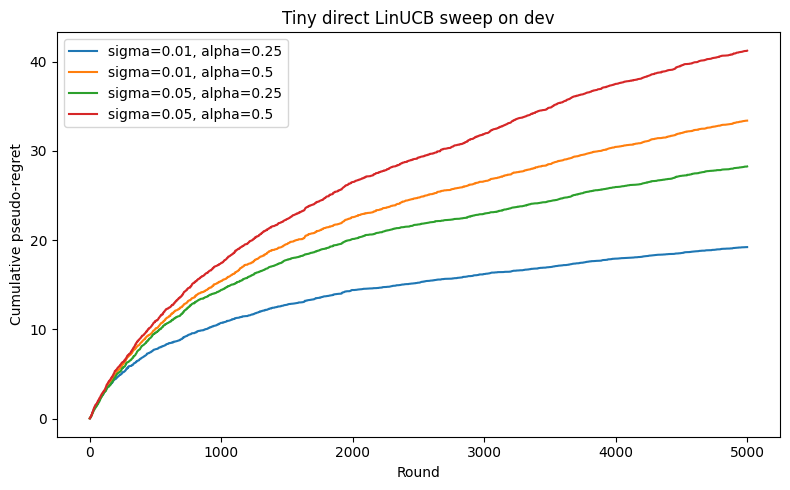


=== Best config in tiny sweep ===
sigma                          0.010000
alpha                          0.250000
lam                            1.000000
seed                           0.000000
n_rounds                    5000.000000
final_regret                  19.222475
avg_chosen_mean                0.038153
avg_optimal_mean               0.041998
chosen_logged_click_rate       0.159600
Name: 0, dtype: float64


In [12]:
# === Step 11 (light): tiny direct LinUCB sweep on dev with tqdm ===

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

sigmas = [0.01, 0.05]
alphas = [0.25, 0.5]
lam = 1.0
seed = 0
n_rounds = 5000

grid = list(itertools.product(sigmas, alphas))
print("Total runs:", len(grid))

rows = []
curves = {}

for sigma, alpha in tqdm(grid, desc="Tiny direct LinUCB sweep"):
    out = run_direct_linucb_dev(
        n_rounds=n_rounds,
        lam=lam,
        alpha=alpha,
        sigma=sigma,
        seed=seed,
    )

    rows.append({
        "sigma": sigma,
        "alpha": alpha,
        "lam": lam,
        "seed": seed,
        "n_rounds": n_rounds,
        "final_regret": out["final_regret"],
        "avg_chosen_mean": out["avg_chosen_mean"],
        "avg_optimal_mean": out["avg_optimal_mean"],
        "chosen_logged_click_rate": out["chosen_logged_click_rate"],
    })

    curves[(sigma, alpha)] = out["cum_regret"]

tiny_sweep_df = pd.DataFrame(rows).sort_values(["sigma", "final_regret", "alpha"]).reset_index(drop=True)
display(tiny_sweep_df)

tiny_sweep_path = processed_dir / "direct_linucb_tiny_sweep_dev.csv"
tiny_sweep_df.to_csv(tiny_sweep_path, index=False)
print("\nSaved:", tiny_sweep_path)

# Plot all 4 regret curves together
plt.figure(figsize=(8, 5))
for (sigma, alpha), curve in curves.items():
    plt.plot(curve, label=f"sigma={sigma}, alpha={alpha}")
plt.xlabel("Round")
plt.ylabel("Cumulative pseudo-regret")
plt.title("Tiny direct LinUCB sweep on dev")
plt.legend()
plt.tight_layout()
plt.show()

best_row = tiny_sweep_df.iloc[0]
print("\n=== Best config in tiny sweep ===")
print(best_row)

rounds_train: (156965, 13)
rounds_dev: (73152, 13)
Z_train: (51282, 32)
Z_dev: (42416, 32)
H_train: (156965, 32)
H_dev: (73152, 32)


Q_train:   0%|          | 0/156965 [00:00<?, ?it/s]

Q_dev:   0%|          | 0/73152 [00:00<?, ?it/s]

Q_train shape: (156965, 98)
Q_dev shape: (73152, 98)
Unique train states: 20
Unique dev states: 19


Transitions on dev:   0%|          | 0/50000 [00:00<?, ?it/s]


=== State occupancy ===
Min occupancy: 0
Median occupancy: 1492.0
Max occupancy: 23124

=== One-step transition diagnostics ===
Mean self-transition prob across states: 0.3144774566256974
Stationary-weighted self-transition prob: 0.5012593881915214
Mean top-1 outgoing transition mass: 0.49495082886209063

=== Spectral dependence proxy ===
SLEM (second-largest eigenvalue modulus): 1.0


Lag diagnostics:   0%|          | 0/15 [00:00<?, ?it/s]


=== Lag decay diagnostics ===
lag= 1 | weighted TV to pi_hat=0.4102 | lag-pred-acc=0.5497
lag= 2 | weighted TV to pi_hat=0.2948 | lag-pred-acc=0.5309
lag= 3 | weighted TV to pi_hat=0.2331 | lag-pred-acc=0.4731
lag= 4 | weighted TV to pi_hat=0.1915 | lag-pred-acc=0.4560
lag= 5 | weighted TV to pi_hat=0.1640 | lag-pred-acc=0.4292
lag= 6 | weighted TV to pi_hat=0.1446 | lag-pred-acc=0.3944
lag= 7 | weighted TV to pi_hat=0.1315 | lag-pred-acc=0.4101
lag= 8 | weighted TV to pi_hat=0.1234 | lag-pred-acc=0.4848
lag= 9 | weighted TV to pi_hat=0.1175 | lag-pred-acc=0.4200
lag=10 | weighted TV to pi_hat=0.1127 | lag-pred-acc=0.4167
lag=11 | weighted TV to pi_hat=0.1091 | lag-pred-acc=0.4286
lag=12 | weighted TV to pi_hat=0.1063 | lag-pred-acc=0.4444
lag=13 | weighted TV to pi_hat=0.1038 | lag-pred-acc=0.4286
lag=14 | weighted TV to pi_hat=0.1017 | lag-pred-acc=0.4000
lag=15 | weighted TV to pi_hat=0.0998 | lag-pred-acc=0.3333

Baseline mode-state accuracy: 0.31610892388451445


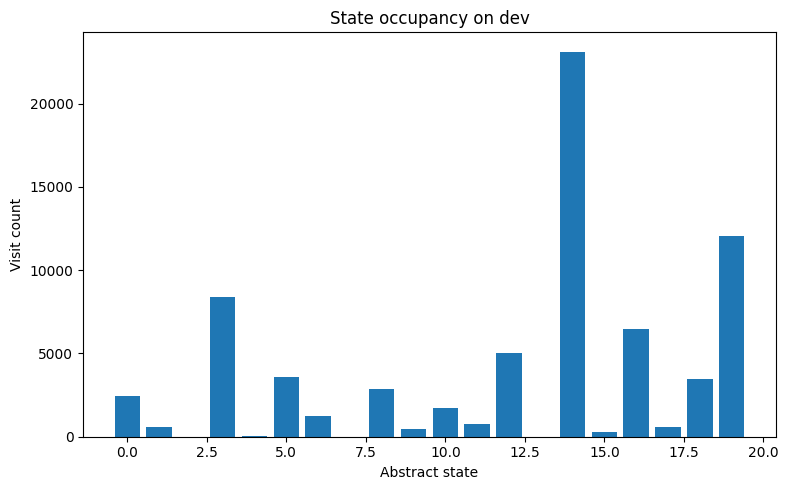

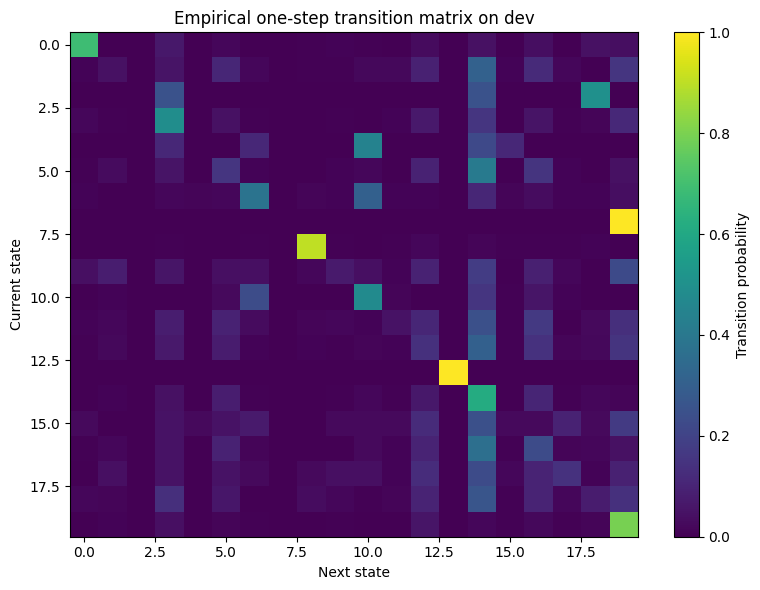

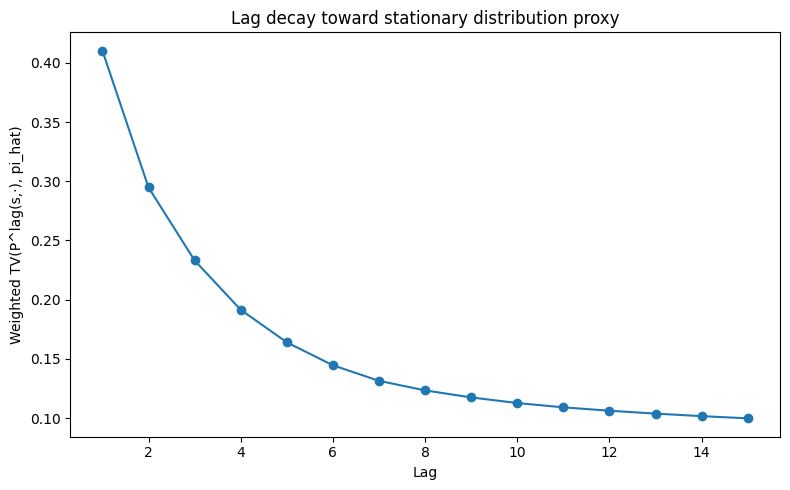

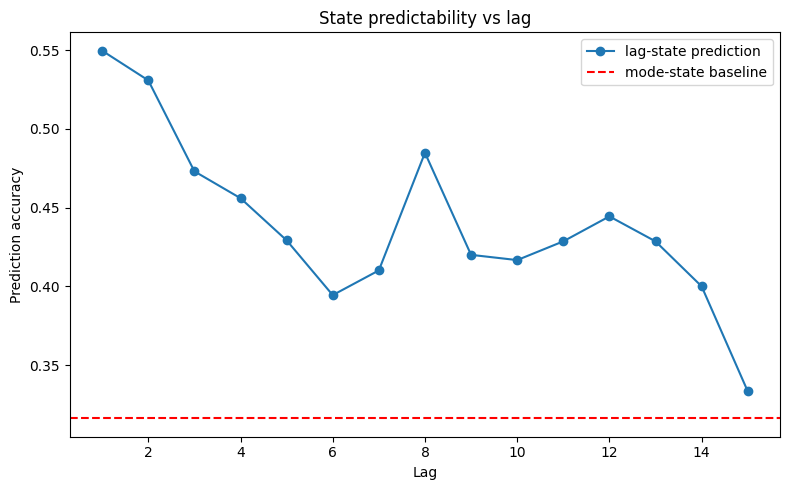


Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\P_hat_dev.npy
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\pi_hat_dev.npy
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\rounds_dev_with_states.pkl
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\rounds_train_with_states.pkl
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\markov_diagnostics_dev.csv
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\markov_summary_dev.csv


In [13]:
# === Step 12: dependence / Markovianity diagnostics on MIND ===
# Uses a coarse state abstraction from impression summaries q_t,
# then estimates empirical transitions on dev and checks lag decay.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

processed_dir = repo_root / "data" / "processed"

# -----------------------------
# 1) Load processed objects
# -----------------------------
rounds_train = pd.read_pickle(processed_dir / "rounds_train_with_rows.pkl")
rounds_dev   = pd.read_pickle(processed_dir / "rounds_dev_with_rows.pkl")

Z_train = np.load(processed_dir / "article_features_train.npy")
Z_dev   = np.load(processed_dir / "article_features_dev.npy")

H_train = np.load(processed_dir / "history_embeddings_train.npy")
H_dev   = np.load(processed_dir / "history_embeddings_dev.npy")

print("rounds_train:", rounds_train.shape)
print("rounds_dev:", rounds_dev.shape)
print("Z_train:", Z_train.shape)
print("Z_dev:", Z_dev.shape)
print("H_train:", H_train.shape)
print("H_dev:", H_dev.shape)

# -----------------------------
# 2) Build impression summary q_t
# -----------------------------
# q_t should summarize the available candidate set and the pre-round history.
# We use:
#   mean candidate embedding (32)
#   std candidate embedding  (32)
#   history embedding        (32)
#   log(num_candidates), log(1+history_len)  (2)
# total dim = 98

def build_q_matrix(rounds_df, Z, H, desc="build_q"):
    rows = []
    for i in tqdm(range(len(rounds_df)), desc=desc):
        cand_rows = rounds_df.iloc[i]["A_t_feature_rows"]
        Zcand = Z[cand_rows]  # shape (K_t, 32)

        cand_mean = Zcand.mean(axis=0)
        cand_std  = Zcand.std(axis=0)

        h_t = H[i]

        scalars = np.array([
            np.log1p(rounds_df.iloc[i]["mapped_num_candidates"]),
            np.log1p(rounds_df.iloc[i]["mapped_history_len"]),
        ], dtype=np.float32)

        q_t = np.concatenate([cand_mean, cand_std, h_t, scalars]).astype(np.float32)
        rows.append(q_t)

    return np.vstack(rows)

Q_train = build_q_matrix(rounds_train, Z_train, H_train, desc="Q_train")
Q_dev   = build_q_matrix(rounds_dev, Z_dev, H_dev, desc="Q_dev")

print("Q_train shape:", Q_train.shape)
print("Q_dev shape:", Q_dev.shape)

# -----------------------------
# 3) Standardize + cluster into coarse states
# -----------------------------
# Keep it modest; we want a coarse state abstraction, not overfitting.
S = 20

scaler = StandardScaler()
Q_train_scaled = scaler.fit_transform(Q_train)
Q_dev_scaled   = scaler.transform(Q_dev)

kmeans = MiniBatchKMeans(
    n_clusters=S,
    random_state=0,
    batch_size=4096,
    n_init=10,
)

state_train = kmeans.fit_predict(Q_train_scaled)
state_dev   = kmeans.predict(Q_dev_scaled)

print("Unique train states:", len(np.unique(state_train)))
print("Unique dev states:", len(np.unique(state_dev)))

# Save states into copies for convenience
rounds_train_states = rounds_train.copy()
rounds_dev_states   = rounds_dev.copy()
rounds_train_states["state"] = state_train
rounds_dev_states["state"]   = state_dev

# -----------------------------
# 4) Estimate transition matrix on dev, respecting user boundaries
# -----------------------------
P_counts = np.zeros((S, S), dtype=np.float64)
state_visit_counts = np.zeros(S, dtype=np.float64)

for user_id, g in tqdm(rounds_dev_states.groupby("user_id", sort=False), desc="Transitions on dev"):
    g = g.sort_values(["time", "impression_id"])
    states = g["state"].to_numpy()

    for s in states:
        state_visit_counts[s] += 1

    if len(states) < 2:
        continue

    for t in range(len(states) - 1):
        P_counts[states[t], states[t + 1]] += 1

# Row-normalize with safe handling for empty rows
P_hat = np.zeros_like(P_counts)
for i in range(S):
    row_sum = P_counts[i].sum()
    if row_sum > 0:
        P_hat[i] = P_counts[i] / row_sum
    else:
        P_hat[i, i] = 1.0  # degenerate fallback

# Empirical stationary distribution proxy from dev state visits
pi_hat = state_visit_counts / np.maximum(state_visit_counts.sum(), 1.0)

print("\n=== State occupancy ===")
print("Min occupancy:", int(state_visit_counts.min()))
print("Median occupancy:", float(np.median(state_visit_counts)))
print("Max occupancy:", int(state_visit_counts.max()))

print("\n=== One-step transition diagnostics ===")
self_transition_rate = float(np.mean(np.diag(P_hat)))
weighted_self_transition = float(np.sum(pi_hat * np.diag(P_hat)))
top1_mass = float(np.mean(P_hat.max(axis=1)))

print("Mean self-transition prob across states:", self_transition_rate)
print("Stationary-weighted self-transition prob:", weighted_self_transition)
print("Mean top-1 outgoing transition mass:", top1_mass)

# -----------------------------
# 5) Spectral / mixing-style proxy
# -----------------------------
# For a finite-state approximation, the second-largest eigenvalue modulus
# gives a practical dependence summary. Smaller => faster mixing.
eigvals = np.linalg.eigvals(P_hat)
eigvals_abs_sorted = np.sort(np.abs(eigvals))[::-1]
slem = float(eigvals_abs_sorted[1]) if len(eigvals_abs_sorted) > 1 else 0.0

print("\n=== Spectral dependence proxy ===")
print("SLEM (second-largest eigenvalue modulus):", slem)

# -----------------------------
# 6) Lag decay diagnostics
# -----------------------------
# We compare P^ell(s, .) to pi_hat using weighted TV distance:
# TV(p, q) = 0.5 * sum_j |p_j - q_j|
# If this decays with ell, that supports a mixing story.

max_lag = 15
tv_by_lag = []
pred_acc_by_lag = []
baseline_mode_state = int(np.argmax(pi_hat))

for lag in tqdm(range(1, max_lag + 1), desc="Lag diagnostics"):
    P_lag = np.linalg.matrix_power(P_hat, lag)

    # Weighted TV distance to stationary distribution
    tv_lag = 0.0
    for s in range(S):
        tv_lag += pi_hat[s] * 0.5 * np.abs(P_lag[s] - pi_hat).sum()
    tv_by_lag.append(float(tv_lag))

    # Simple predictive-accuracy diagnostic:
    # predict state_{t+lag} by argmax of P^lag(state_t, ·)
    total = 0
    correct = 0

    for user_id, g in rounds_dev_states.groupby("user_id", sort=False):
        g = g.sort_values(["time", "impression_id"])
        states = g["state"].to_numpy()

        if len(states) <= lag:
            continue

        for t in range(len(states) - lag):
            s_now = states[t]
            s_future = states[t + lag]
            s_pred = int(np.argmax(P_lag[s_now]))
            correct += int(s_pred == s_future)
            total += 1

    pred_acc_by_lag.append(correct / total if total > 0 else np.nan)

# Baseline accuracy from always predicting the most common state
baseline_total = 0
baseline_correct = 0
for user_id, g in rounds_dev_states.groupby("user_id", sort=False):
    states = g.sort_values(["time", "impression_id"])["state"].to_numpy()
    for s in states:
        baseline_correct += int(s == baseline_mode_state)
        baseline_total += 1
baseline_acc = baseline_correct / baseline_total

print("\n=== Lag decay diagnostics ===")
for lag, tv, acc in zip(range(1, max_lag + 1), tv_by_lag, pred_acc_by_lag):
    print(f"lag={lag:2d} | weighted TV to pi_hat={tv:.4f} | lag-pred-acc={acc:.4f}")

print("\nBaseline mode-state accuracy:", baseline_acc)

# -----------------------------
# 7) Plots
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(np.arange(S), state_visit_counts)
plt.xlabel("Abstract state")
plt.ylabel("Visit count")
plt.title("State occupancy on dev")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(P_hat, aspect="auto")
plt.colorbar(label="Transition probability")
plt.xlabel("Next state")
plt.ylabel("Current state")
plt.title("Empirical one-step transition matrix on dev")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_lag + 1), tv_by_lag, marker="o")
plt.xlabel("Lag")
plt.ylabel("Weighted TV(P^lag(s,·), pi_hat)")
plt.title("Lag decay toward stationary distribution proxy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_lag + 1), pred_acc_by_lag, marker="o", label="lag-state prediction")
plt.axhline(baseline_acc, color="red", linestyle="--", label="mode-state baseline")
plt.xlabel("Lag")
plt.ylabel("Prediction accuracy")
plt.title("State predictability vs lag")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Save outputs
# -----------------------------
np.save(processed_dir / "P_hat_dev.npy", P_hat)
np.save(processed_dir / "pi_hat_dev.npy", pi_hat)
rounds_dev_states.to_pickle(processed_dir / "rounds_dev_with_states.pkl")
rounds_train_states.to_pickle(processed_dir / "rounds_train_with_states.pkl")

diag_df = pd.DataFrame({
    "lag": np.arange(1, max_lag + 1),
    "weighted_tv_to_pi": tv_by_lag,
    "lag_prediction_accuracy": pred_acc_by_lag,
})
diag_df.to_csv(processed_dir / "markov_diagnostics_dev.csv", index=False)

summary_markov = pd.DataFrame([{
    "num_states": S,
    "slem": slem,
    "mean_self_transition_prob": self_transition_rate,
    "weighted_self_transition_prob": weighted_self_transition,
    "mean_top1_outgoing_mass": top1_mass,
    "baseline_mode_state_accuracy": baseline_acc,
}])
summary_markov.to_csv(processed_dir / "markov_summary_dev.csv", index=False)

print("\nSaved:")
print(processed_dir / "P_hat_dev.npy")
print(processed_dir / "pi_hat_dev.npy")
print(processed_dir / "rounds_dev_with_states.pkl")
print(processed_dir / "rounds_train_with_states.pkl")
print(processed_dir / "markov_diagnostics_dev.csv")
print(processed_dir / "markov_summary_dev.csv")

rounds_train: (156965, 13)
rounds_dev: (73152, 13)
Z_train: (51282, 32)
Z_dev: (42416, 32)
H_train: (156965, 32)
H_dev: (73152, 32)

=== Dev user trajectory length diagnostics ===
count    50000.000000
mean         1.463040
std          0.909907
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         18.000000
Name: count, dtype: float64
Users with >= 2 impressions : 14826
Users with >= 3 impressions : 4984
Users with >= 5 impressions : 786
Users with >= 10 impressions: 26
Users with >= 15 impressions: 2
Users with >= 20 impressions: 0


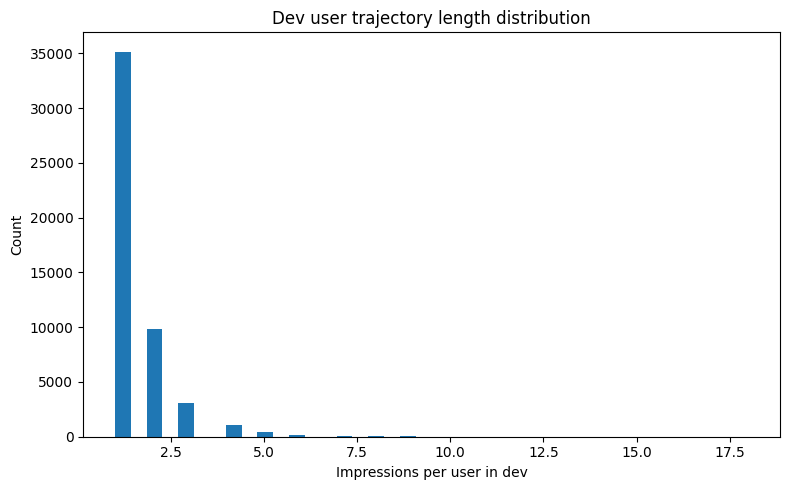


After filtering dev users:
min_user_len: 5
rounds_dev_f: (4587, 13)
num kept dev users: 786


Q_train_full:   0%|          | 0/156965 [00:00<?, ?it/s]

Q_dev_filtered:   0%|          | 0/4587 [00:00<?, ?it/s]


Q_train shape: (156965, 98)
Q_dev_f shape: (4587, 98)

Unique raw train states: 20
Unique raw filtered-dev states: 17

After remapping occupied dev states:
S_eff: 17
Occupied dev states: [0, 1, 3, 4, 5, 6, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]


Transitions on filtered dev:   0%|          | 0/786 [00:00<?, ?it/s]


Users with >=1 transition: 786
Total transitions used: 3801

=== State occupancy ===
Min occupancy: 2
Median occupancy: 69.0
Max occupancy: 1554

=== One-step transition diagnostics ===
Mean self-transition prob across states: 0.3026425764974231
Stationary-weighted self-transition prob: 0.47614978719926365
Mean top-1 outgoing transition mass: 0.4782429824403134

=== Spectral dependence proxy ===
SLEM: 0.907830284994407


Lag diagnostics:   0%|          | 0/15 [00:00<?, ?it/s]


=== Lag decay diagnostics ===
lag= 1 | weighted TV to pi_hat=0.3615 | lag-pred-acc=0.5270
lag= 2 | weighted TV to pi_hat=0.2385 | lag-pred-acc=0.5045
lag= 3 | weighted TV to pi_hat=0.1773 | lag-pred-acc=0.4594
lag= 4 | weighted TV to pi_hat=0.1391 | lag-pred-acc=0.4505
lag= 5 | weighted TV to pi_hat=0.1140 | lag-pred-acc=0.4292
lag= 6 | weighted TV to pi_hat=0.0980 | lag-pred-acc=0.3944
lag= 7 | weighted TV to pi_hat=0.0873 | lag-pred-acc=0.3596
lag= 8 | weighted TV to pi_hat=0.0809 | lag-pred-acc=0.4141
lag= 9 | weighted TV to pi_hat=0.0766 | lag-pred-acc=0.4200
lag=10 | weighted TV to pi_hat=0.0732 | lag-pred-acc=0.4167
lag=11 | weighted TV to pi_hat=0.0704 | lag-pred-acc=0.4286
lag=12 | weighted TV to pi_hat=0.0681 | lag-pred-acc=0.4444
lag=13 | weighted TV to pi_hat=0.0663 | lag-pred-acc=0.4286
lag=14 | weighted TV to pi_hat=0.0647 | lag-pred-acc=0.4000
lag=15 | weighted TV to pi_hat=0.0634 | lag-pred-acc=0.3333

Baseline mode-state accuracy: 0.33878351863963374


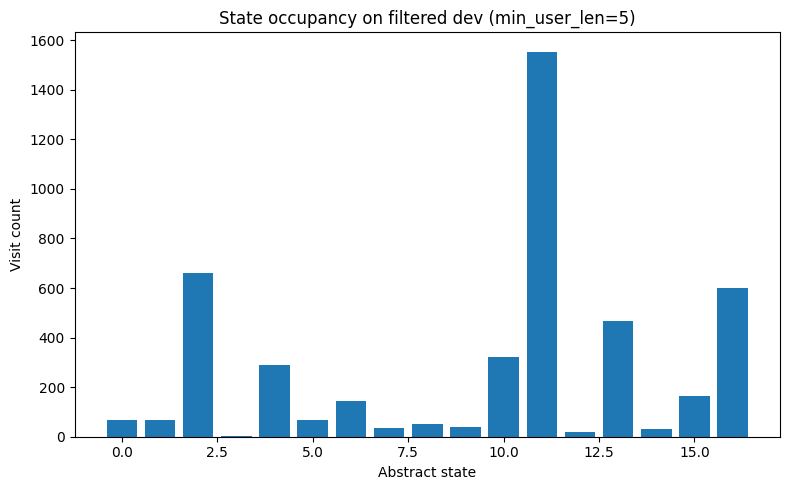

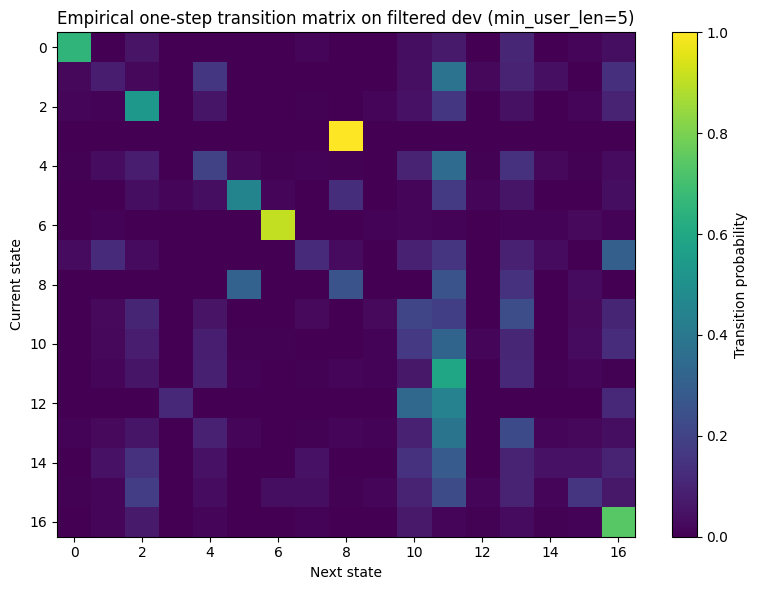

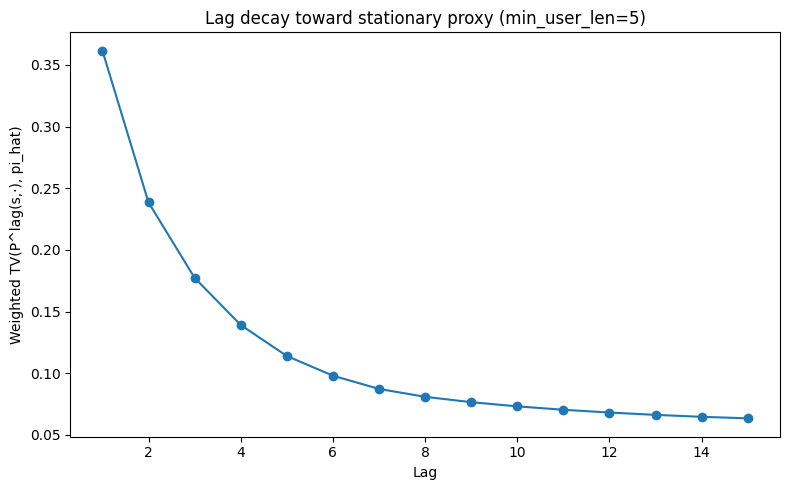

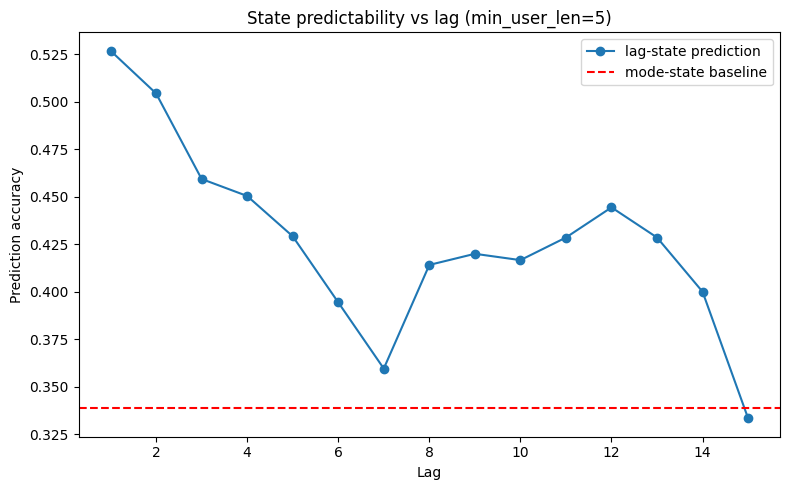


Saved:
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\markov_diagnostics_dev_minuser5.csv
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\markov_summary_dev_minuser5.csv
D:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\rounds_dev_with_states_minuser5.pkl


In [18]:
# === Dependence diagnostics: previous "better" version + longer-user dev filtering ===
# Keeps:
#   - full train-based clustering
#   - richer q_t = [cand_mean, cand_std, history_emb, log(num_candidates), log(history_len)]
#   - lag-decay / P^lag diagnostics
# Adds:
#   - filter dev users by min_user_len BEFORE transition estimation
#   - remap occupied dev states to avoid empty-state artifacts
#   - extra prints for how many users/transitions survive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

processed_dir = repo_root / "data" / "processed"

# -----------------------------
# 1) Load processed objects
# -----------------------------
rounds_train = pd.read_pickle(processed_dir / "rounds_train_with_rows.pkl")
rounds_dev   = pd.read_pickle(processed_dir / "rounds_dev_with_rows.pkl")

Z_train = np.load(processed_dir / "article_features_train.npy")
Z_dev   = np.load(processed_dir / "article_features_dev.npy")

H_train = np.load(processed_dir / "history_embeddings_train.npy")
H_dev   = np.load(processed_dir / "history_embeddings_dev.npy")

print("rounds_train:", rounds_train.shape)
print("rounds_dev:", rounds_dev.shape)
print("Z_train:", Z_train.shape)
print("Z_dev:", Z_dev.shape)
print("H_train:", H_train.shape)
print("H_dev:", H_dev.shape)

# -----------------------------
# 2) Inspect dev user trajectory lengths and filter
# -----------------------------
dev_counts = rounds_dev["user_id"].value_counts()

print("\n=== Dev user trajectory length diagnostics ===")
print(dev_counts.describe())
print("Users with >= 2 impressions :", int((dev_counts >= 2).sum()))
print("Users with >= 3 impressions :", int((dev_counts >= 3).sum()))
print("Users with >= 5 impressions :", int((dev_counts >= 5).sum()))
print("Users with >= 10 impressions:", int((dev_counts >= 10).sum()))
print("Users with >= 15 impressions:", int((dev_counts >= 15).sum()))
print("Users with >= 20 impressions:", int((dev_counts >= 20).sum()))

plt.figure(figsize=(8, 5))
plt.hist(dev_counts.values, bins=40)
plt.xlabel("Impressions per user in dev")
plt.ylabel("Count")
plt.title("Dev user trajectory length distribution")
plt.tight_layout()
plt.show()

# Choose this manually after seeing the counts.
# Start with 5. If too small/large, rerun with 3 or 10.
min_user_len = 5

keep_dev_users = set(dev_counts[dev_counts >= min_user_len].index)
mask_dev = rounds_dev["user_id"].isin(keep_dev_users)

rounds_dev_f = rounds_dev.loc[mask_dev].copy().reset_index(drop=True)
H_dev_f = H_dev[mask_dev.to_numpy()]

print("\nAfter filtering dev users:")
print("min_user_len:", min_user_len)
print("rounds_dev_f:", rounds_dev_f.shape)
print("num kept dev users:", rounds_dev_f["user_id"].nunique())

if len(rounds_dev_f) == 0:
    raise ValueError("Filtering removed all dev rows. Lower min_user_len.")

# -----------------------------
# 3) Build q_t exactly like the earlier 'better' code
#    q_t = [cand_mean(32), cand_std(32), h_t(32), log1p(K_t), log1p(history_len)]
#    total dim = 98
# -----------------------------
def build_q_matrix(rounds_df, Z, H, desc="build_q"):
    rows = []
    for i in tqdm(range(len(rounds_df)), desc=desc):
        cand_rows = rounds_df.iloc[i]["A_t_feature_rows"]
        Zcand = Z[cand_rows]  # shape (K_t, 32)

        # defensive guards
        if len(cand_rows) == 0:
            cand_mean = np.zeros(Z.shape[1], dtype=np.float32)
            cand_std  = np.zeros(Z.shape[1], dtype=np.float32)
        else:
            cand_mean = Zcand.mean(axis=0).astype(np.float32)
            cand_std  = Zcand.std(axis=0).astype(np.float32)

        h_t = H[i].astype(np.float32)

        scalars = np.array([
            np.log1p(rounds_df.iloc[i]["mapped_num_candidates"]),
            np.log1p(rounds_df.iloc[i]["mapped_history_len"]),
        ], dtype=np.float32)

        q_t = np.concatenate([cand_mean, cand_std, h_t, scalars]).astype(np.float32)
        rows.append(q_t)

    if len(rows) == 0:
        raise ValueError("No q_t rows were built.")
    return np.vstack(rows)

Q_train = build_q_matrix(rounds_train, Z_train, H_train, desc="Q_train_full")
Q_dev_f = build_q_matrix(rounds_dev_f, Z_dev, H_dev_f, desc="Q_dev_filtered")

print("\nQ_train shape:", Q_train.shape)
print("Q_dev_f shape:", Q_dev_f.shape)

# -----------------------------
# 4) Train-based clustering exactly like the earlier version
# -----------------------------
S = 20  # same as earlier code; change only if you want

scaler = StandardScaler()
Q_train_scaled = scaler.fit_transform(Q_train)
Q_dev_f_scaled = scaler.transform(Q_dev_f)

kmeans = MiniBatchKMeans(
    n_clusters=S,
    random_state=0,
    batch_size=4096,
    n_init=10,
)

state_train = kmeans.fit_predict(Q_train_scaled)
state_dev_f = kmeans.predict(Q_dev_f_scaled)

rounds_train_states = rounds_train.copy()
rounds_dev_states   = rounds_dev_f.copy()

rounds_train_states["state_raw"] = state_train
rounds_dev_states["state_raw"]   = state_dev_f

print("\nUnique raw train states:", len(np.unique(state_train)))
print("Unique raw filtered-dev states:", len(np.unique(state_dev_f)))

# -----------------------------
# 5) Remap only occupied dev states to contiguous labels
#    This preserves the old pipeline but avoids empty-state artifacts.
# -----------------------------
occupied = sorted(rounds_dev_states["state_raw"].unique().tolist())
remap = {old: new for new, old in enumerate(occupied)}

rounds_dev_states["state"] = rounds_dev_states["state_raw"].map(remap)
rounds_train_states = rounds_train_states[rounds_train_states["state_raw"].isin(occupied)].copy()
rounds_train_states["state"] = rounds_train_states["state_raw"].map(remap)

S_eff = len(occupied)

print("\nAfter remapping occupied dev states:")
print("S_eff:", S_eff)
print("Occupied dev states:", occupied)

# -----------------------------
# 6) Estimate transition matrix on filtered dev, respecting user boundaries
# -----------------------------
P_counts = np.zeros((S_eff, S_eff), dtype=np.float64)
state_visit_counts = np.zeros(S_eff, dtype=np.float64)

num_users_with_transitions = 0
num_total_transitions = 0

for user_id, g in tqdm(rounds_dev_states.groupby("user_id", sort=False), desc="Transitions on filtered dev"):
    g = g.sort_values(["time", "impression_id"])
    states = g["state"].to_numpy()

    for s in states:
        state_visit_counts[s] += 1

    if len(states) < 2:
        continue

    num_users_with_transitions += 1
    num_total_transitions += (len(states) - 1)

    for t in range(len(states) - 1):
        P_counts[states[t], states[t + 1]] += 1

print("\nUsers with >=1 transition:", num_users_with_transitions)
print("Total transitions used:", num_total_transitions)

# Row-normalize with safe handling for empty rows
P_hat = np.zeros_like(P_counts)
for i in range(S_eff):
    row_sum = P_counts[i].sum()
    if row_sum > 0:
        P_hat[i] = P_counts[i] / row_sum
    else:
        P_hat[i, i] = 1.0

pi_hat = state_visit_counts / np.maximum(state_visit_counts.sum(), 1.0)

print("\n=== State occupancy ===")
print("Min occupancy:", int(state_visit_counts.min()))
print("Median occupancy:", float(np.median(state_visit_counts)))
print("Max occupancy:", int(state_visit_counts.max()))

print("\n=== One-step transition diagnostics ===")
self_transition_rate = float(np.mean(np.diag(P_hat)))
weighted_self_transition = float(np.sum(pi_hat * np.diag(P_hat)))
top1_mass = float(np.mean(P_hat.max(axis=1)))

print("Mean self-transition prob across states:", self_transition_rate)
print("Stationary-weighted self-transition prob:", weighted_self_transition)
print("Mean top-1 outgoing transition mass:", top1_mass)

# -----------------------------
# 7) Spectral / mixing-style proxy
# -----------------------------
eigvals = np.linalg.eigvals(P_hat)
eigvals_abs_sorted = np.sort(np.abs(eigvals))[::-1]
slem = float(eigvals_abs_sorted[1]) if len(eigvals_abs_sorted) > 1 else 0.0

print("\n=== Spectral dependence proxy ===")
print("SLEM:", slem)

# -----------------------------
# 8) Lag decay diagnostics exactly like earlier version
# -----------------------------
max_lag = 15
tv_by_lag = []
pred_acc_by_lag = []
baseline_mode_state = int(np.argmax(pi_hat))

# Prebuild filtered dev state sequences once
user_state_lists = []
for user_id, g in rounds_dev_states.groupby("user_id", sort=False):
    g = g.sort_values(["time", "impression_id"])
    user_state_lists.append(g["state"].to_numpy())

for lag in tqdm(range(1, max_lag + 1), desc="Lag diagnostics"):
    P_lag = np.linalg.matrix_power(P_hat, lag)

    # weighted TV to empirical stationary proxy
    tv_lag = 0.0
    for s in range(S_eff):
        tv_lag += pi_hat[s] * 0.5 * np.abs(P_lag[s] - pi_hat).sum()
    tv_by_lag.append(float(tv_lag))

    # lag-state prediction from argmax of P^lag
    total = 0
    correct = 0

    for states in user_state_lists:
        if len(states) <= lag:
            continue
        for t in range(len(states) - lag):
            s_now = states[t]
            s_future = states[t + lag]
            s_pred = int(np.argmax(P_lag[s_now]))
            correct += int(s_pred == s_future)
            total += 1

    pred_acc_by_lag.append(correct / total if total > 0 else np.nan)

# baseline = always predict modal state
baseline_total = 0
baseline_correct = 0
for states in user_state_lists:
    for s in states:
        baseline_correct += int(s == baseline_mode_state)
        baseline_total += 1
baseline_acc = baseline_correct / baseline_total

print("\n=== Lag decay diagnostics ===")
for lag, tv, acc in zip(range(1, max_lag + 1), tv_by_lag, pred_acc_by_lag):
    print(f"lag={lag:2d} | weighted TV to pi_hat={tv:.4f} | lag-pred-acc={acc:.4f}")

print("\nBaseline mode-state accuracy:", baseline_acc)

# -----------------------------
# 9) Plots
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(np.arange(S_eff), state_visit_counts)
plt.xlabel("Abstract state")
plt.ylabel("Visit count")
plt.title(f"State occupancy on filtered dev (min_user_len={min_user_len})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(P_hat, aspect="auto")
plt.colorbar(label="Transition probability")
plt.xlabel("Next state")
plt.ylabel("Current state")
plt.title(f"Empirical one-step transition matrix on filtered dev (min_user_len={min_user_len})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_lag + 1), tv_by_lag, marker="o")
plt.xlabel("Lag")
plt.ylabel("Weighted TV(P^lag(s,·), pi_hat)")
plt.title(f"Lag decay toward stationary proxy (min_user_len={min_user_len})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_lag + 1), pred_acc_by_lag, marker="o", label="lag-state prediction")
plt.axhline(baseline_acc, color="red", linestyle="--", label="mode-state baseline")
plt.xlabel("Lag")
plt.ylabel("Prediction accuracy")
plt.title(f"State predictability vs lag (min_user_len={min_user_len})")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10) Save outputs
# -----------------------------
diag_df = pd.DataFrame({
    "lag": np.arange(1, max_lag + 1),
    "weighted_tv_to_pi": tv_by_lag,
    "lag_prediction_accuracy": pred_acc_by_lag,
})

summary_markov = pd.DataFrame([{
    "num_states_requested": S,
    "num_states_effective": S_eff,
    "min_user_len": min_user_len,
    "num_kept_dev_users": rounds_dev_states["user_id"].nunique(),
    "num_total_transitions": num_total_transitions,
    "slem": slem,
    "mean_self_transition_prob": self_transition_rate,
    "weighted_self_transition_prob": weighted_self_transition,
    "mean_top1_outgoing_mass": top1_mass,
    "baseline_mode_state_accuracy": baseline_acc,
}])

diag_path = processed_dir / f"markov_diagnostics_dev_minuser{min_user_len}.csv"
summary_path = processed_dir / f"markov_summary_dev_minuser{min_user_len}.csv"
rounds_path = processed_dir / f"rounds_dev_with_states_minuser{min_user_len}.pkl"

diag_df.to_csv(diag_path, index=False)
summary_markov.to_csv(summary_path, index=False)
rounds_dev_states.to_pickle(rounds_path)

print("\nSaved:")
print(diag_path)
print(summary_path)
print(rounds_path)